#**Análise Exploratória dos dados**

In [74]:
#Conjunto de Imports para funcionamento de todas as células do notebook
import os
import urllib.request
from pathlib import Path
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import countDistinct
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
from pyspark.sql.functions import min as spark_min, max as spark_max, col
import seaborn as sns
from pyspark.sql.types import DoubleType
from pyspark.sql.functions import (
    sum as spark_sum,
    round as spark_round,
    when,
    col,
    avg,
    count
)


In [75]:
#Início da engine para o projeto
spark = SparkSession.builder.appName("eda_taxi").getOrCreate()

url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
destino = Path(os.getcwd()) / "data/yellow_tripdata_2024-01.parquet"
destino.parent.mkdir(parents=True, exist_ok=True)

if not destino.exists():
    urllib.request.urlretrieve(url, destino)

df = spark.read.parquet(str(destino))

In [76]:
print(df.filter(col("improvement_surcharge") == 0.3).count()/df.count())

0.00019361645861330139


In [77]:
url_zone_lookup = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
destino_zone = Path(os.getcwd()) / "data" / "taxi_zone_lookup.csv"
destino_zone.parent.mkdir(parents=True, exist_ok=True)

urllib.request.urlretrieve(url_zone_lookup, destino_zone)

zone_lookup = spark.read.csv(str(destino_zone), header=True, inferSchema=True)
zone_lookup.printSchema()

root
 |-- LocationID: integer (nullable = true)
 |-- Borough: string (nullable = true)
 |-- Zone: string (nullable = true)
 |-- service_zone: string (nullable = true)



# **1. Analisar descrição das colunas fornecida em documentação**

Fonte: https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf

<p>Dicionários de outros tipos de viagem e metadados (como as TLC Taxi Zones):<br>
http://www.nyc.gov/html/tlc/html/about/trip_record_data.shtml</p>

<table style="font-size:12px; border-collapse:collapse;">
<thead>
<tr>
<th style="border:1px solid #ccc; padding:4px;">Coluna</th>
<th style="border:1px solid #ccc; padding:4px;">Descrição</th>
<th style="border:1px solid #ccc; padding:4px;">Domínio / códigos</th>
</tr>
</thead>
<tbody>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>VendorID</code></td>
<td style="border:1px solid #ccc; padding:4px;">Código que indica o provedor TPEP que forneceu o registro.</td>
<td style="border:1px solid #ccc; padding:4px;">1 = Creative Mobile Technologies, LLC<br>2 = Curb Mobility, LLC<br>6 = Myle Technologies Inc<br>7 = Helix</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>tpep_pickup_datetime</code></td>
<td style="border:1px solid #ccc; padding:4px;">Data e hora em que o taxímetro foi acionado.</td>
<td style="border:1px solid #ccc; padding:4px;">—</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>tpep_dropoff_datetime</code></td>
<td style="border:1px solid #ccc; padding:4px;">Data e hora em que o taxímetro foi desligado.</td>
<td style="border:1px solid #ccc; padding:4px;">—</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>passenger_count</code></td>
<td style="border:1px solid #ccc; padding:4px;">Número de passageiros no veículo.</td>
<td style="border:1px solid #ccc; padding:4px;">—</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>trip_distance</code></td>
<td style="border:1px solid #ccc; padding:4px;">Distância percorrida na viagem, em milhas, reportada pelo taxímetro.</td>
<td style="border:1px solid #ccc; padding:4px;">—</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>RatecodeID</code></td>
<td style="border:1px solid #ccc; padding:4px;">Código tarifário final vigente ao término da viagem.</td>
<td style="border:1px solid #ccc; padding:4px;">1 = Tarifa padrão<br>2 = JFK<br>3 = Newark<br>4 = Nassau ou Westchester<br>5 = Tarifa negociada<br>6 = Corrida em grupo<br>99 = Nulo/desconhecido</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>store_and_fwd_flag</code></td>
<td style="border:1px solid #ccc; padding:4px;">Indica se o registro da viagem ficou retido na memória do veículo antes de ser enviado ao provedor ("store and forward"), porque o veículo não tinha conexão com o servidor.</td>
<td style="border:1px solid #ccc; padding:4px;">Y = viagem store and forward<br>N = viagem não store and forward</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>PULocationID</code></td>
<td style="border:1px solid #ccc; padding:4px;">TLC Taxi Zone na qual o taxímetro foi acionado.</td>
<td style="border:1px solid #ccc; padding:4px;">Ver <code>taxi_zone_lookup.csv</code></td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>DOLocationID</code></td>
<td style="border:1px solid #ccc; padding:4px;">TLC Taxi Zone na qual o taxímetro foi desligado.</td>
<td style="border:1px solid #ccc; padding:4px;">Ver <code>taxi_zone_lookup.csv</code></td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>payment_type</code></td>
<td style="border:1px solid #ccc; padding:4px;">Código numérico que indica como o passageiro pagou pela viagem.</td>
<td style="border:1px solid #ccc; padding:4px;">0 = Viagem Flex Fare<br>1 = Cartão de crédito<br>2 = Dinheiro<br>3 = Sem cobrança<br>4 = Contestada (dispute)<br>5 = Desconhecida<br>6 = Viagem anulada (voided)</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>fare_amount</code></td>
<td style="border:1px solid #ccc; padding:4px;">Tarifa por tempo e distância calculada pelo taxímetro. Para informações adicionais sobre as colunas seguintes, ver https://www.nyc.gov/site/tlc/passengers/taxi-fare.page</td>
<td style="border:1px solid #ccc; padding:4px;">—</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>extra</code></td>
<td style="border:1px solid #ccc; padding:4px;">Extras e sobretaxas diversas.</td>
<td style="border:1px solid #ccc; padding:4px;">—</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>mta_tax</code></td>
<td style="border:1px solid #ccc; padding:4px;">Taxa acionada automaticamente com base na tarifa metrificada em uso.</td>
<td style="border:1px solid #ccc; padding:4px;">—</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>tip_amount</code></td>
<td style="border:1px solid #ccc; padding:4px;">Valor da gorjeta. Preenchido automaticamente para gorjetas em cartão de crédito. <strong>Gorjetas em dinheiro não são incluídas.</strong></td>
<td style="border:1px solid #ccc; padding:4px;">—</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>tolls_amount</code></td>
<td style="border:1px solid #ccc; padding:4px;">Valor total de todos os pedágios pagos na viagem.</td>
<td style="border:1px solid #ccc; padding:4px;">—</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>improvement_surcharge</code></td>
<td style="border:1px solid #ccc; padding:4px;">Sobretaxa de melhoria aplicada às viagens no acionamento do taxímetro (flag drop). Passou a ser cobrada em 2015.</td>
<td style="border:1px solid #ccc; padding:4px;">—</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>total_amount</code></td>
<td style="border:1px solid #ccc; padding:4px;">Valor total cobrado dos passageiros. <strong>Não inclui gorjetas em dinheiro.</strong></td>
<td style="border:1px solid #ccc; padding:4px;">—</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>congestion_surcharge</code></td>
<td style="border:1px solid #ccc; padding:4px;">Valor total arrecadado na viagem referente à sobretaxa de congestionamento do estado de Nova York (NYS).</td>
<td style="border:1px solid #ccc; padding:4px;">—</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>airport_fee</code></td>
<td style="border:1px solid #ccc; padding:4px;">Aplicada somente em embarques nos aeroportos LaGuardia e John F. Kennedy.</td>
<td style="border:1px solid #ccc; padding:4px;">—</td>
</tr>
<tr>
<td style="border:1px solid #ccc; padding:4px;"><code>cbd_congestion_fee</code></td>
<td style="border:1px solid #ccc; padding:4px;">Cobrança por viagem referente à Congestion Relief Zone da MTA, <strong>a partir de 05/01/2025</strong>.</td>
<td style="border:1px solid #ccc; padding:4px;">Não presente em jan/2024</td>
</tr>
</tbody>
</table>

# **2. Investigar tipos das colunas**

In [78]:
df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



# **3. Investigar volume do data frame**

In [79]:
# Volume do dataset bruto
print(f"{df.count()} linhas, {len(df.columns)} colunas")

2964624 linhas, 19 colunas


# **4. Investigar cardinalidade**

In [80]:
df.select([countDistinct(c).alias(c) for c in df.columns]).show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       3|             1575706|              1574780|             10|         4489|         7|                 2|         260|         261|           5|       8970|   48|      8|      419

In [81]:
colunas_categoricas = ["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag", "PULocationID", "DOLocationID"]

resultado = df.select([countDistinct(c).alias(c) for c in colunas_categoricas]).collect()[0]

for coluna in colunas_categoricas:
    print(f"{coluna}: {resultado[coluna]} valores distintos")

VendorID: 3 valores distintos
RatecodeID: 7 valores distintos
payment_type: 5 valores distintos
store_and_fwd_flag: 2 valores distintos
PULocationID: 260 valores distintos
DOLocationID: 261 valores distintos


In [82]:
colunas_categoricas1 = ["passenger_count"]

for coluna in colunas_categoricas1:
    valores = [linha[0] for linha in df.select(coluna).distinct().collect()]
    valores_ordenados = sorted(valores, key=lambda x: (x is None, x))
    print(f"{coluna}: {valores_ordenados}")

passenger_count: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, None]


In [83]:
colunas_categoricas1 = ["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag"]

for coluna in colunas_categoricas1:
    valores = [linha[0] for linha in df.select(coluna).distinct().collect()]
    valores_ordenados = sorted(valores, key=lambda x: (x is None, x))
    print(f"{coluna}: {valores_ordenados}")

VendorID: [1, 2, 6]
RatecodeID: [1, 2, 3, 4, 5, 6, 99, None]
payment_type: [0, 1, 2, 3, 4]
store_and_fwd_flag: ['N', 'Y', None]


In [84]:
colunas_categoricas2 = ["PULocationID", "DOLocationID"]

for coluna in colunas_categoricas2:
    valores = [linha[0] for linha in df.select(coluna).distinct().collect()]
    valores_ordenados = sorted(valores, key=lambda x: (x is None, x))
    print(f"{coluna}: {valores_ordenados}")

PULocationID: [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 100, 101, 102, 105, 106, 107, 108, 109, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 

Fonte 1: https://www.nyc.gov/site/tlc/passengers/taxi-fare.page

Fonte 2: https://www.tax.ny.gov/bus/taxi/

Com base nestas fontes oficiais do governo de NY pudemos aferir que:

Confirmação das regras tarifárias — fonte TLC

**Fonte:** [Taxi Fare - TLC](https://www.nyc.gov/site/tlc/passengers/taxi-fare.page) (consultado em 18/07/2026)

**mta_tax**
Regra confirmada: 50 centavos de MTA State Surcharge para viagens que terminam em NYC ou nos condados de Nassau, Suffolk, Westchester, Rockland, Dutchess, Orange ou Putnam.
Status: bate com "fixa (0.50), condicionada ao destino".

**improvement_surcharge**
Regra confirmada: US$ 1,00, presente em todos os regimes tarifários listados (standard, fora da cidade, JFK).
Status: sustenta o "incondicional".

**congestion_surcharge**
Regra confirmada: US$ 2,50 (táxi amarelo) para viagens que começam, terminam ou passam por Manhattan ao sul da rua 96.
Status: bate com "condicionada geograficamente".

Observação: a página reflete as regras vigentes na data de consulta, não necessariamente as de jan/2024 (período dos dados) — vale citar a data de acesso na documentação, como feito acima.

<div style="font-size:12px; line-height:1.3;">

<h4 style="margin-bottom:2px;">Segmentação das colunas por tipo:</h4>

<p style="margin-bottom:2px; margin-top:8px;"><strong>Categóricas</strong></p>

<p style="margin-bottom:2px; margin-top:4px; margin-left:20px;">Identificadores</p>
<ul style="margin-top:2px; margin-bottom:4px; margin-left:20px;">
<li><code>VendorID</code> — código do provedor TPEP</li>
<li><code>RatecodeID</code> — código tarifário</li>
<li><code>payment_type</code> — código do meio de pagamento</li>
<li><code>PULocationID</code> — código da zona de embarque</li>
<li><code>DOLocationID</code> — código da zona de desembarque</li>
</ul>

<p style="margin-bottom:2px; margin-top:4px; margin-left:20px;">Binária/flag</p>
<ul style="margin-top:2px; margin-bottom:4px; margin-left:20px;">
<li><code>store_and_fwd_flag</code> — indica se o registro foi retido no veículo antes do envio (Y/N)</li>
</ul>

<p style="margin-bottom:2px; margin-top:8px;"><strong>Temporais</strong></p>
<ul style="margin-top:2px; margin-bottom:4px; margin-left:20px;">
<li><code>tpep_pickup_datetime</code> — data/hora de acionamento do taxímetro</li>
<li><code>tpep_dropoff_datetime</code> — data/hora de desligamento do taxímetro</li>
</ul>

<p style="margin-bottom:2px; margin-top:8px;"><strong>Numéricas</strong></p>

<p style="margin-bottom:2px; margin-top:4px; margin-left:20px;">Contínuas</p>
<ul style="margin-top:2px; margin-bottom:4px; margin-left:20px;">
<li><code>trip_distance</code> — distância percorrida na viagem, em milhas</li>
<li><code>fare_amount</code> — tarifa por tempo e distância calculada pelo taxímetro</li>
<li><code>extra</code> — extras e sobretaxas diversas</li>
<li><code>mta_tax</code> — taxa acionada automaticamente com base na tarifa metrificada</li>
<li><code>tip_amount</code> — valor da gorjeta (não inclui gorjetas em dinheiro)</li>
<li><code>tolls_amount</code> — valor total de pedágios pagos na viagem</li>
<li><code>improvement_surcharge</code> — sobretaxa de melhoria aplicada no acionamento do taxímetro</li>
<li><code>total_amount</code> — valor total cobrado dos passageiros (não inclui gorjetas em dinheiro)</li>
<li><code>congestion_surcharge</code> — sobretaxa de congestionamento do estado de Nova York</li>
<li><code>Airport_fee</code> — taxa aplicada em embarques nos aeroportos LaGuardia e JFK</li>
</ul>

<p style="margin-bottom:2px; margin-top:4px; margin-left:20px;">Discretas</p>
<ul style="margin-top:2px; margin-bottom:4px; margin-left:20px;">
<li><code>passenger_count</code> — número de passageiros no veículo</li>
</ul>

</div>

**OBS:** Com base nas informações obtidas até então é importante destacar a mistura de atributos ocorrida na coluna 'payment_type', dado que tal coluna mistura informações de payment type com a ocorrência de disputa e não cobrança da corrida

# **5. Investigando valores nulos**

In [85]:
df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c) for c in df.columns
]).show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       0|                   0|                    0|         140162|            0|    140162|            140162|           0|           0|           0|          0|    0|      0|         

In [86]:
colunas_com_nulos = ["passenger_count", "RatecodeID", "store_and_fwd_flag", "congestion_surcharge", "Airport_fee"]

condicao = None
for c in colunas_com_nulos:
    if condicao is None:
        condicao = col(c).isNull()
    else:
        condicao = condicao & col(c).isNull()

qtd_todas_nulas = df.filter(condicao).count()
print(f"Linhas com todas as colunas nulas ao mesmo tempo: {qtd_todas_nulas}")

Linhas com todas as colunas nulas ao mesmo tempo: 140162


In [87]:
colunas_com_nulos = ["passenger_count", "RatecodeID", "store_and_fwd_flag", "congestion_surcharge", "Airport_fee"]

condicao = None
for c in colunas_com_nulos:
    if condicao is None:
        condicao = col(c).isNull()
    else:
        condicao = condicao & col(c).isNull()

df.filter(condicao).sample(fraction=0.001, seed=42).show(10, truncate=False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|2       |2024-01-01 00:34:15 |2024-01-01 00:59:34  |NULL           |6.33         |NULL      |NULL              |190         |63          |0           |30.59      |0.0  |0.5    |0.0      

In [88]:
colunas_com_nulos = ["passenger_count", "RatecodeID", "store_and_fwd_flag", "congestion_surcharge", "Airport_fee"]

condicao = None
for c in colunas_com_nulos:
    if condicao is None:
        condicao = col(c).isNull()
    else:
        condicao = condicao & col(c).isNull()

colunas_categoricas = ["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag", "PULocationID", "DOLocationID"]

for categoria in colunas_categoricas:
    total_por_categoria = df.groupBy(categoria).count().withColumnRenamed("count", "total_linhas")
    nulos_por_categoria = df.filter(condicao).groupBy(categoria).count().withColumnRenamed("count", "linhas_nulas")

    resultado = total_por_categoria.join(
        nulos_por_categoria,
        on=total_por_categoria[categoria].eqNullSafe(nulos_por_categoria[categoria]),
        how="left"
    ).select(
        total_por_categoria[categoria],
        "total_linhas",
        "linhas_nulas"
    ).fillna(0, subset=["linhas_nulas"]) \
    .withColumn("percentual_nulos", spark_round((col("linhas_nulas") / col("total_linhas")) * 100, 2)) \
    .orderBy(categoria)

    print(f"\n=== Distribuição de nulos por {categoria} ===")
    resultado.show(truncate=False)


=== Distribuição de nulos por VendorID ===
+--------+------------+------------+----------------+
|VendorID|total_linhas|linhas_nulas|percentual_nulos|
+--------+------------+------------+----------------+
|1       |729732      |48455       |6.64            |
|2       |2234632     |91447       |4.09            |
|6       |260         |260         |100.0           |
+--------+------------+------------+----------------+


=== Distribuição de nulos por RatecodeID ===
+----------+------------+------------+----------------+
|RatecodeID|total_linhas|linhas_nulas|percentual_nulos|
+----------+------------+------------+----------------+
|NULL      |140162      |140162      |100.0           |
|1         |2663350     |0           |0.0             |
|2         |98713       |0           |0.0             |
|3         |7954        |0           |0.0             |
|4         |6365        |0           |0.0             |
|5         |19410       |0           |0.0             |
|6         |7           |0 

<div style="font-size:12px; line-height:1.3;">

<h4 style="margin-bottom:2px;">Distribuição de nulos por coluna categórica</h4>

<p style="margin-bottom:2px; margin-top:8px;"><strong>Achado principal — vínculo com <code>payment_type</code></strong></p>
<ul style="margin-top:2px; margin-bottom:4px;">
<li><code>payment_type = 0</code> (Flex Fare) concentra <strong>100% dos nulos</strong>: 140.162 linhas totais, todas com <code>RatecodeID</code>, <code>store_and_fwd_flag</code>, <code>passenger_count</code>, <code>congestion_surcharge</code> e <code>Airport_fee</code> nulos simultaneamente.</li>
<li>Esse número bate exatamente com o total de linhas nulas identificado anteriormente — indício forte de que o padrão de nulos está ligado ao tipo de pagamento, não a uma fonte ou região específica.</li>
</ul>

<p style="margin-bottom:2px; margin-top:8px;"><strong><code>VendorID</code> não explica o padrão</strong></p>
<ul style="margin-top:2px; margin-bottom:4px;">
<li><code>VendorID = 6</code> tem 100% de nulos, mas representa apenas 260 linhas — volume irrisório.</li>
<li><code>VendorID = 1</code> (6,64%) e <code>VendorID = 2</code> (4,09%) têm nulos distribuídos, sem concentração total.</li>
<li>A soma dos nulos entre os três vendors (48.455 + 91.447 + 260) bate com o total de 140.162 — os nulos estão espalhados entre provedores, o que descarta a hipótese de ser característica exclusiva de uma fonte.</li>
</ul>

<p style="margin-bottom:2px; margin-top:8px;"><strong><code>PULocationID</code> e <code>DOLocationID</code> reforçam a conclusão</strong></p>
<ul style="margin-top:2px; margin-bottom:4px;">
<li>Percentuais de nulo espalhados entre zonas (1% a mais de 30%), sem concentração clara em nenhuma zona específica — indício de que a causa não é geográfica.</li>
</ul>

<p style="margin-bottom:2px; margin-top:8px;"><strong>Conclusão</strong></p>
<ul style="margin-top:2px; margin-bottom:4px;">
<li>O padrão de nulos parece estar associado ao tipo de pagamento <strong>Flex Fare</strong> (<code>payment_type = 0</code>), e não a um provedor ou região específicos — plausível, já que esse tipo de tarifa provavelmente não passa pelo fluxo padrão de tarifação nem pelo mecanismo tradicional de armazenamento do taxímetro.</li>
</ul>

</div>

In [89]:
df.filter(col("payment_type") == 0).select(
    spark_sum(when(col("RatecodeID").isNotNull(), 1).otherwise(0)).alias("ratecode_nao_nulo")
).show()

+-----------------+
|ratecode_nao_nulo|
+-----------------+
|                0|
+-----------------+



Confirmação: nulos ligados ao `payment_type = 0`

Nenhuma linha com `payment_type = 0` (Flex Fare) tem `RatecodeID` preenchido — confirma que o padrão de nulos é uma característica sistemática desse tipo de pagamento, não erro ou dado faltante aleatório. Viagens Flex Fare parecem não passar pelo mesmo processo de captura que gera `RatecodeID`, `store_and_fwd_flag`, `passenger_count`, `congestion_surcharge` e `Airport_fee`.

**Implicação para o tratamento:** um `dropna()` descartaria uma categoria válida de pagamento, não sujeira nos dados. Faz mais sentido preencher esses campos com um valor sentinela de "não aplicável" do que remover as linhas.

# **6. Distribuição estatística - variáveis categóricas**

In [90]:
def distribuicao_categorica(df, coluna):
    total = df.count()
    return (df.groupBy(coluna)
              .count()
              .withColumn("frequencia_relativa_%", F.round(F.col("count") / total * 100, 2))
              .orderBy(coluna))

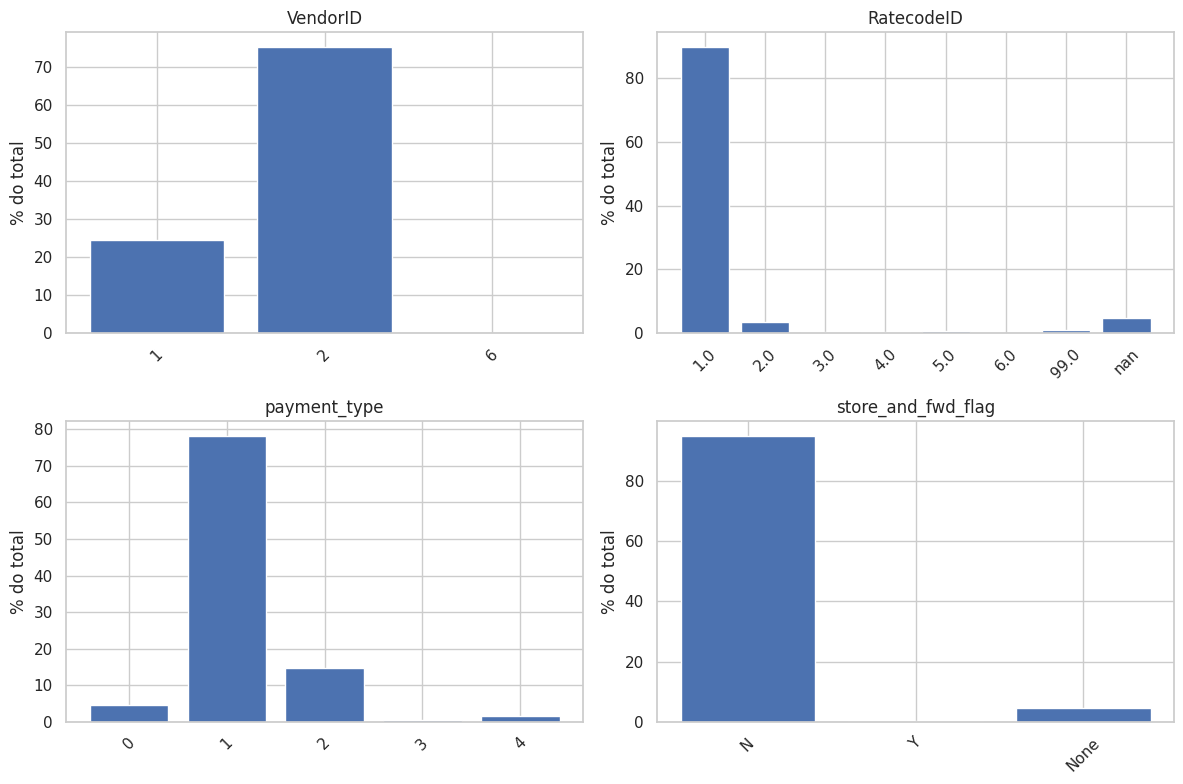

In [91]:
colunas_baixa_cardinalidade = ["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, coluna in zip(axes.flat, colunas_baixa_cardinalidade):
    pdf = distribuicao_categorica(df, coluna).toPandas().sort_values(coluna, ascending=True)
    ax.bar(pdf[coluna].astype(str), pdf["frequencia_relativa_%"])
    ax.set_title(coluna)
    ax.set_ylabel("% do total")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [92]:
def tabela_com_nomes(df, coluna, zone_lookup):
    distribuicao = distribuicao_categorica(df, coluna)

    resultado = distribuicao.join(
        zone_lookup,
        distribuicao[coluna] == zone_lookup["LocationID"],
        how="left"
    ).select(
        col(coluna).alias("LocationID"),
        col("Zone").alias("nome_zona"),
        col("Borough").alias("borough"),
        "frequencia_relativa_%"
    ).orderBy(col("frequencia_relativa_%").desc())

    return resultado

tabela_pu = tabela_com_nomes(df, "PULocationID", zone_lookup)
tabela_pu.show(n=300, truncate=False)

tabela_do = tabela_com_nomes(df, "DOLocationID", zone_lookup)
tabela_do.show(n=300, truncate=False)

+----------+---------------------------------------------+-------------+---------------------+
|LocationID|nome_zona                                    |borough      |frequencia_relativa_%|
+----------+---------------------------------------------+-------------+---------------------+
|132       |JFK Airport                                  |Queens       |4.9                  |
|161       |Midtown Center                               |Manhattan    |4.84                 |
|237       |Upper East Side South                        |Manhattan    |4.81                 |
|236       |Upper East Side North                        |Manhattan    |4.6                  |
|162       |Midtown East                                 |Manhattan    |3.6                  |
|230       |Times Sq/Theatre District                    |Manhattan    |3.59                 |
|186       |Penn Station/Madison Sq West                 |Manhattan    |3.53                 |
|142       |Lincoln Square East                   

# **7. Domínio das variáveis numéricas**

In [93]:
colunas_numericas = [
    "passenger_count", "trip_distance", "fare_amount", "extra", "mta_tax",
    "tip_amount", "tolls_amount", "improvement_surcharge", "total_amount",
    "congestion_surcharge", "Airport_fee"
]

for coluna in colunas_numericas:
    linha = df.select(
        spark_min(col(coluna)).alias("min"),
        spark_max(col(coluna)).alias("max")
    ).collect()[0]
    print(f"{coluna}: [{linha['min']}, {linha['max']}]")

passenger_count: [0, 9]
trip_distance: [0.0, 312722.3]
fare_amount: [-899.0, 5000.0]
extra: [-7.5, 14.25]
mta_tax: [-0.5, 4.0]
tip_amount: [-80.0, 428.0]
tolls_amount: [-80.0, 115.92]
improvement_surcharge: [-1.0, 1.0]
total_amount: [-900.0, 5000.0]
congestion_surcharge: [-2.5, 2.5]
Airport_fee: [-1.75, 1.75]


# **8. Estatísticas básicas das colunas numéricas**

In [94]:
#Primeira visualização
colunas_numericas = [
    "passenger_count", "trip_distance", "fare_amount", "extra", "mta_tax",
    "tip_amount", "tolls_amount", "improvement_surcharge", "total_amount",
    "congestion_surcharge", "Airport_fee"
]

# 1. Estatísticas gerais
print("Estatísticas descritivas")
resumo = df.select(colunas_numericas).summary(
    "count", "mean", "stddev", "min", "25%", "50%", "75%", "max"
)
colunas_valores = [c for c in resumo.columns if c != "summary"]
resumo.select(
    "summary",
    *[F.round(F.col(c).cast("double"), 2).alias(c) for c in colunas_valores]
).show()

# 2. Colunas com outliers extremos
print("Colunas com percentuais extremos")
cauda = df.select("trip_distance", "fare_amount", "total_amount").summary(
    "min", "1%", "5%", "50%", "95%", "99%", "max"
)
cauda.select(
    "summary",
    *[F.round(F.col(c).cast("double"), 2).alias(c) for c in cauda.columns if c != "summary"]
).show()


Estatísticas descritivas
+-------+---------------+-------------+-----------+---------+---------+----------+------------+---------------------+------------+--------------------+-----------+
|summary|passenger_count|trip_distance|fare_amount|    extra|  mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+-------+---------------+-------------+-----------+---------+---------+----------+------------+---------------------+------------+--------------------+-----------+
|  count|      2824462.0|    2964624.0|  2964624.0|2964624.0|2964624.0| 2964624.0|   2964624.0|            2964624.0|   2964624.0|           2824462.0|  2824462.0|
|   mean|           1.34|         3.65|      18.18|     1.45|     0.48|      3.34|        0.53|                 0.98|        26.8|                2.26|       0.14|
| stddev|           0.85|       225.46|      18.95|      1.8|     0.12|       3.9|        2.13|                 0.22|       23.39|                0.82|    

`Contagem (count)`: O número total de observações de dados não nulos.

`Média (mean)`: A média de todos os valores, calculada como a soma dos dados divididos pela contagem.

`Desvio Padrão (Stddev)`: Uma medida de dispersão dos valores em relação à média. Um desvio padrão baixo indica que os pontos de dados estão próximos da média, enquanto um valor alto indica uma variação maior.

`Mín. (min)`: O menor valor numérico no conjunto de dados.

`Máx. (max)`: O maior valor numérico no conjunto de dados.

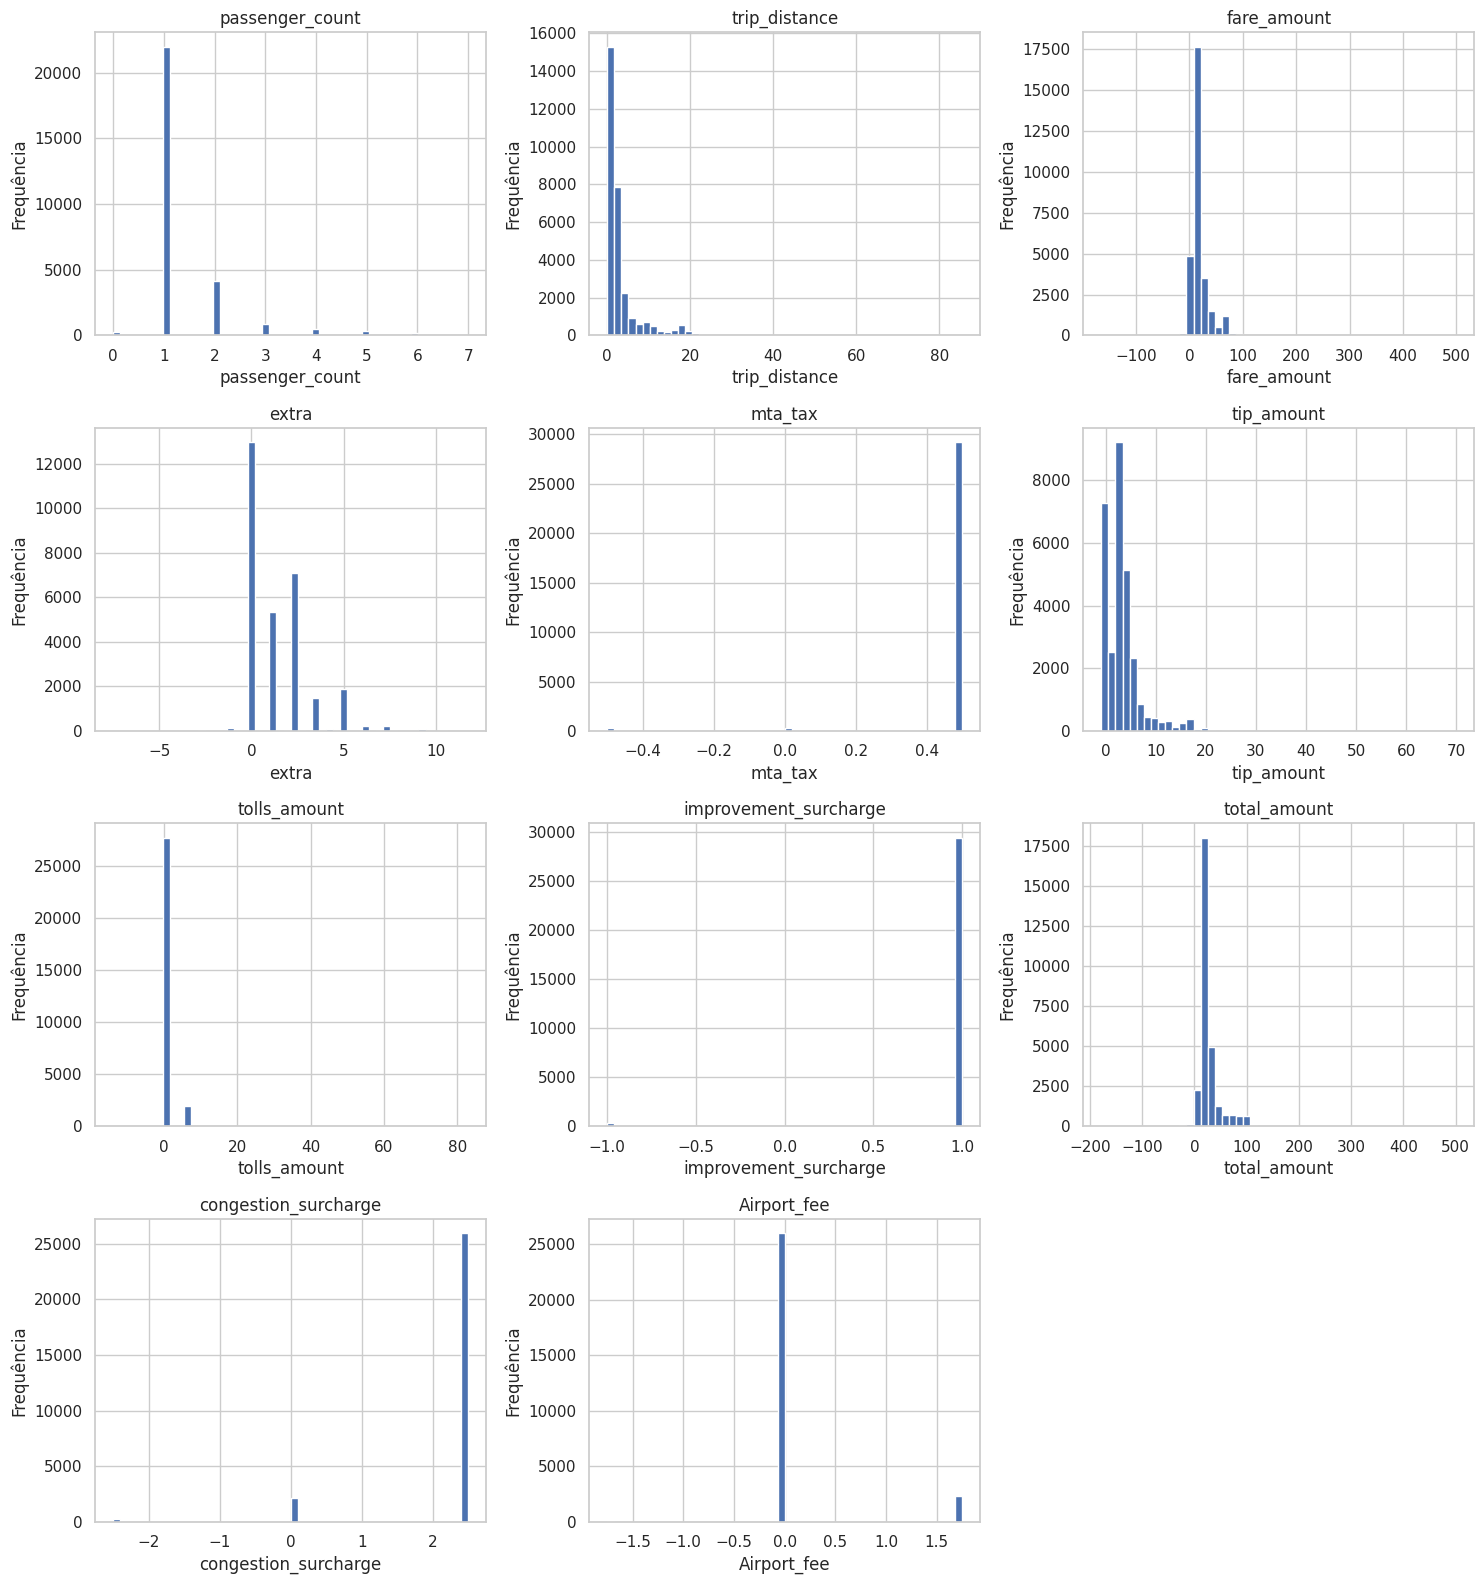

In [95]:
colunas_numericas = [
    "passenger_count", "trip_distance", "fare_amount", "extra", "mta_tax",
    "tip_amount", "tolls_amount", "improvement_surcharge", "total_amount",
    "congestion_surcharge", "Airport_fee"
]

# Amostra de 1% (~30 mil linhas) — suficiente para o formato da distribuição
pdf = df.select(colunas_numericas).sample(fraction=0.01, seed=42).toPandas()

fig, axes = plt.subplots(4, 3, figsize=(15, 16))

for ax, coluna in zip(axes.flat, colunas_numericas):
    # Corta em p1-p99 para os extremos não achatarem o gráfico
    p1, p99 = df.approxQuantile(coluna, [0.01, 0.99], 0.01)
    serie = pdf[coluna].dropna()
    serie = serie[(serie >= p1) & (serie <= p99)]

    ax.hist(serie, bins=50)
    ax.set_title(coluna)
    ax.set_xlabel(coluna)
    ax.set_ylabel("Frequência")

# Esconde o 12º subplot, que fica sem variável
axes.flat[11].set_visible(False)

plt.tight_layout()
plt.show()

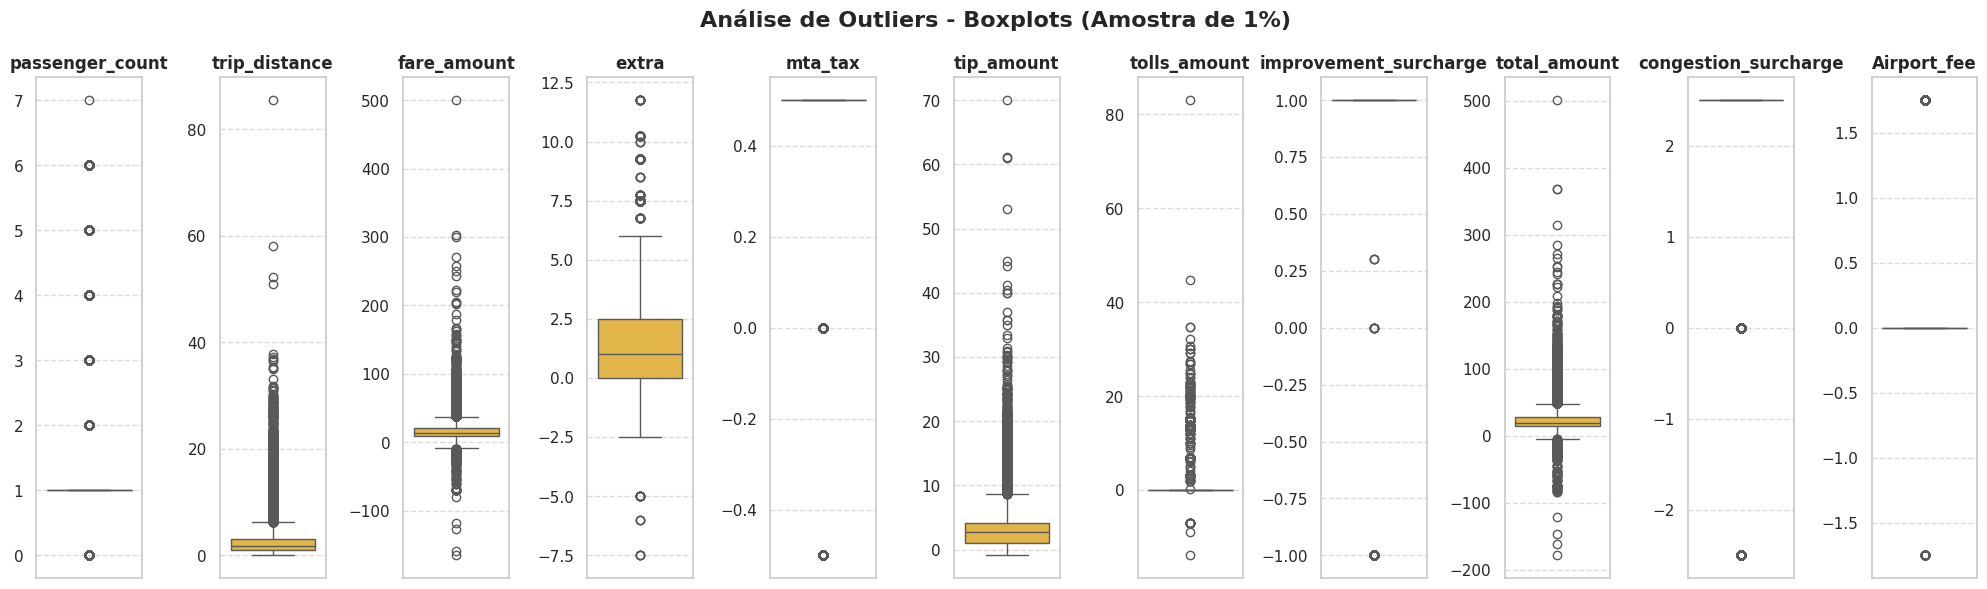

In [96]:
fig, axes = plt.subplots(1, len(colunas_numericas), figsize=(20, 6))
fig.suptitle("Análise de Outliers - Boxplots (Amostra de 1%)", fontsize=16, fontweight='bold')

for i, col in enumerate(colunas_numericas):
    sns.boxplot(data=pdf, y=col, ax=axes[i], color='#FBC02D')
    axes[i].set_title(col, fontsize=12, fontweight='semibold')
    axes[i].set_ylabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **9. Análise de outliers e anomalias**

## **9.1. Análise de inconsistências temporais**

### **9.1.1. Registros de corridas fora do dominio esperado de Janeiro de 2024**

In [97]:
# Total de linhas para cálculo relativo
total_rows = df.count()

# Identifica corridas fora de Jan/2024
df_out_of_dates = df.filter(
    (F.col("tpep_pickup_datetime") < "2024-01-01 00:00:00") |
    (F.col("tpep_pickup_datetime") > "2024-01-31 23:59:59")
)

out_of_dates_count = df_out_of_dates.count()

print(f"=== ANÁLISE TEMPORAL: ESCOPO DE DATAS ===")
print(f"Total de registros: {total_rows:,}")
print(f"Fora de Jan/2024:   {out_of_dates_count:,} ({(out_of_dates_count / total_rows) * 100:.4f}%)\n")

# Exibe os anos/meses que foram capturados erroneamente
df_out_of_dates.select(
    F.date_format("tpep_pickup_datetime", "yyyy-MM").alias("Ano_Mês_Incorreto")
).groupBy("Ano_Mês_Incorreto").count().orderBy("count", ascending=False).show()

=== ANÁLISE TEMPORAL: ESCOPO DE DATAS ===
Total de registros: 2,964,624
Fora de Jan/2024:   18 (0.0006%)

+-----------------+-----+
|Ano_Mês_Incorreto|count|
+-----------------+-----+
|          2023-12|   10|
|          2009-01|    3|
|          2024-02|    3|
|          2002-12|    2|
+-----------------+-----+



### **9.1.2. Outliers de trip_duration_min**

Segundo a [TLC de Nova York](https://www.nyc.gov/site/tlc/about/fatigued-driving-prevention-frequently-asked-questions.page), motoristas de táxi e FHV não podem acumular mais de 10 horas de passenger time (tempo entre o embarque e o desembarque de passageiros) em um período de 24 horas, nem mais de 60 horas em uma semana-calendário (segunda a domingo).

In [98]:
# Adiciona a coluna de duração em minutos
df = df.withColumn(
    "trip_duration_min",
    F.round((F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60.0, 2)
)

# Filtra durações anômalas
df_invalid_duration = df.filter(
    (F.col("trip_duration_min") <= 0) | (F.col("trip_duration_min") > 1440)
)

invalid_duration_count = df_invalid_duration.count()

print(f"=== ANÁLISE TEMPORAL: DURAÇÃO DA VIAGEM ===")
print(f"Durações inválidas (<= 0 min ou > 24h): {invalid_duration_count:,} ({(invalid_duration_count / total_rows) * 100:.4f}%)\n")

# Resumo estatístico da duração das corridas
df.select("trip_duration_min").describe().show()

=== ANÁLISE TEMPORAL: DURAÇÃO DA VIAGEM ===
Durações inválidas (<= 0 min ou > 24h): 886 (0.0299%)

+-------+------------------+
|summary| trip_duration_min|
+-------+------------------+
|  count|           2964624|
|   mean|15.612948444726756|
| stddev| 34.85105477793078|
|    min|            -13.57|
|    max|            9455.4|
+-------+------------------+



In [99]:
limite_10h_em_min = 10 * 60  # 600 minutos

qtd = df.filter(F.col("trip_duration_min") > limite_10h_em_min).count()

print(f"Linhas com trip_duration_min > 10h (600 min): {qtd}")

Linhas com trip_duration_min > 10h (600 min): 1651


### **9.1.3 Análise de corridas com tempo negativo**

In [100]:
count_normal = df.filter(F.col("tpep_pickup_datetime") > F.col("tpep_dropoff_datetime")).count()
print(f"Linhas com pickup > dropoff: {count_normal}")

Linhas com pickup > dropoff: 56


In [101]:
df.filter(F.col("tpep_pickup_datetime") > F.col("tpep_dropoff_datetime")).show(56)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+-----------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|trip_duration_min|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+-----------------+
|       1| 2024-01-02 10:00:00|  2024-01-02 09:53:56|              1|          7.2|        99|                 N|          75|       

In [102]:
recorte = df.filter(F.col("tpep_pickup_datetime") > F.col("tpep_dropoff_datetime"))

categoricas = ["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag"]

for col in categoricas:
    print(f"\n=== {col} ===")

    dominio_completo = df.select(col).distinct()
    contagem_recorte = recorte.groupBy(col).count().withColumnRenamed(col, f"{col}_recorte")

    resultado = (dominio_completo
        .join(contagem_recorte,
              dominio_completo[col].eqNullSafe(contagem_recorte[f"{col}_recorte"]),
              how="left")
        .select(col, F.coalesce(F.col("count"), F.lit(0)).alias("count"))
        .orderBy(F.desc("count")))

    resultado.show()


=== VendorID ===
+--------+-----+
|VendorID|count|
+--------+-----+
|       6|   48|
|       1|    8|
|       2|    0|
+--------+-----+


=== RatecodeID ===
+----------+-----+
|RatecodeID|count|
+----------+-----+
|      NULL|   48|
|        99|    8|
|         6|    0|
|         5|    0|
|         1|    0|
|         3|    0|
|         2|    0|
|         4|    0|
+----------+-----+


=== payment_type ===
+------------+-----+
|payment_type|count|
+------------+-----+
|           0|   48|
|           1|    8|
|           3|    0|
|           2|    0|
|           4|    0|
+------------+-----+


=== store_and_fwd_flag ===
+------------------+-----+
|store_and_fwd_flag|count|
+------------------+-----+
|              NULL|   48|
|                 N|    8|
|                 Y|    0|
+------------------+-----+



Em função de serem dados fora do domínio e da pequena representação dessas colunas em todos os registros, estas linhas serão deletadas no tratamento.

## **9.2. Análise de inconsistências monetárias**

### **9.2.1. Validação Matemática da Equação do total_amount**

In [103]:
# Expressão de soma das taxas com tratamento de nulos (coalesce)
calculated_total_expr = (
    F.coalesce(F.col("fare_amount"), F.lit(0)) +
    F.coalesce(F.col("extra"), F.lit(0)) +
    F.coalesce(F.col("mta_tax"), F.lit(0)) +
    F.coalesce(F.col("tip_amount"), F.lit(0)) +
    F.coalesce(F.col("tolls_amount"), F.lit(0)) +
    F.coalesce(F.col("improvement_surcharge"), F.lit(0)) +
    F.coalesce(F.col("congestion_surcharge"), F.lit(0)) +
    F.coalesce(F.col("Airport_fee"), F.lit(0))
)

# Calcula a diferença COM sinal (preserva a direção da divergência)
df_math_check = df \
    .withColumn("calculated_total", F.round(calculated_total_expr, 2)) \
    .withColumn("total_diff", F.round(F.col("total_amount") - F.col("calculated_total"), 2))

# Registros onde a soma não bate (usa abs() só para o filtro de magnitude, não para o valor armazenado)
df_discrepancies = df_math_check.filter(F.abs(F.col("total_diff")) > 0.02)
disc_count = df_discrepancies.count()

print(f"=== ANÁLISE FINANCEIRA: VALIDAÇÃO DA EQUAÇÃO DA TARIFA ===")
print(f"Divergências encontradas: {disc_count:,} ({(disc_count / total_rows) * 100:.4f}%)\n")

# Exemplo dos registros com divergência
df_discrepancies.select("total_amount", "calculated_total", "total_diff", "payment_type").show(10)

=== ANÁLISE FINANCEIRA: VALIDAÇÃO DA EQUAÇÃO DA TARIFA ===
Divergências encontradas: 761,838 (25.6976%)

+------------+----------------+----------+------------+
|total_amount|calculated_total|total_diff|payment_type|
+------------+----------------+----------+------------+
|       18.75|           21.25|      -2.5|           1|
|        31.3|            33.8|      -2.5|           1|
|        17.0|            19.5|      -2.5|           1|
|        16.1|            18.6|      -2.5|           1|
|        41.5|            44.0|      -2.5|           1|
|        30.4|            32.9|      -2.5|           2|
|       23.85|           26.35|      -2.5|           1|
|       85.09|           87.59|      -2.5|           1|
|       12.05|           14.55|      -2.5|           1|
|        11.5|            14.0|      -2.5|           2|
+------------+----------------+----------+------------+
only showing top 10 rows


In [104]:
# Analisa a frequência de cada valor de diferença dentro dos registros divergentes
df_diff_distribution = df_discrepancies \
    .groupBy("total_diff") \
    .agg(
        F.count("*").alias("qtd_ocorrencias"),
        F.round((F.count("*") / disc_count) * 100, 2).alias("pct_do_total_divergente")
    ) \
    .orderBy(F.col("qtd_ocorrencias").desc())

df_diff_distribution.show(15, truncate=False)

+----------+---------------+-----------------------+
|total_diff|qtd_ocorrencias|pct_do_total_divergente|
+----------+---------------+-----------------------+
|-2.5      |591045         |77.58                  |
|2.5       |129332         |16.98                  |
|-4.25     |22451          |2.95                   |
|-1.75     |18149          |2.38                   |
|4.5       |792            |0.1                    |
|2.0       |42             |0.01                   |
|1.95      |23             |0.0                    |
|-1.0      |2              |0.0                    |
|-0.3      |1              |0.0                    |
|1.75      |1              |0.0                    |
+----------+---------------+-----------------------+



In [105]:
# Caso 1: total_diff == -2.5
caso1 = df_discrepancies.filter(F.col("total_diff") == -2.5)
caso1_total = caso1.count()
caso1_match = caso1.filter(F.col("congestion_surcharge") == 2.5).count()
print(f"Caso 1 (-2.5): {caso1_match}/{caso1_total} ({caso1_match/caso1_total*100:.2f}%) têm congestion_surcharge = +2.5")

# Caso 2: total_diff == 2.5
caso2 = df_discrepancies.filter(F.col("total_diff") == 2.5)
caso2_total = caso2.count()
caso2_match = caso2.filter(F.col("congestion_surcharge").isNull()).count()
print(f"Caso 2 (+2.5): {caso2_match}/{caso2_total} ({caso2_match/caso2_total*100:.2f}%) têm congestion_surcharge = NULL")

# Caso 3: total_diff == -4.25
caso3 = df_discrepancies.filter(F.col("total_diff") == -4.25)
caso3_total = caso3.count()
caso3_match = caso3.filter(
    (F.col("congestion_surcharge") == 2.5) & (F.col("Airport_fee") == 1.75)
).count()
print(f"Caso 3 (-4.25): {caso3_match}/{caso3_total} ({caso3_match/caso3_total*100:.2f}%) têm congestion_surcharge = +2.5 e Airport_fee = +1.75")

# Caso 4: total_diff == -1.75
caso4 = df_discrepancies.filter(F.col("total_diff") == -1.75)
caso4_total = caso4.count()
caso4_match = caso4.filter(F.col("Airport_fee") == 1.75).count()
print(f"Caso 4 (-1.75): {caso4_match}/{caso4_total} ({caso4_match/caso4_total*100:.2f}%) têm Airport_fee = +1.75")

Caso 1 (-2.5): 590942/591045 (99.98%) têm congestion_surcharge = +2.5
Caso 2 (+2.5): 125088/129332 (96.72%) têm congestion_surcharge = NULL
Caso 3 (-4.25): 22451/22451 (100.00%) têm congestion_surcharge = +2.5 e Airport_fee = +1.75
Caso 4 (-1.75): 18149/18149 (100.00%) têm Airport_fee = +1.75


Vamos checar se essas corridas com total_diff = -2.5, total_diff = +2.5 e total_diff = -4.25 passam pela região de congestion surcharge. Checar se total_diff = -4.25 e total_diff = -1.75

In [106]:
zonas = spark.read.csv("data/taxi_zone_lookup.csv", header=True, inferSchema=True)

df_com_zonas = (df
    .join(zonas.select(F.col("LocationID").alias("PULocationID"),
                        F.col("Zone").alias("PU_Zone"),
                        F.col("Borough").alias("PU_Borough")), "PULocationID")
    .join(zonas.select(F.col("LocationID").alias("DOLocationID"),
                        F.col("Zone").alias("DO_Zone"),
                        F.col("Borough").alias("DO_Borough")), "DOLocationID")
)

calculated_total_expr = (
    F.coalesce(F.col("fare_amount"), F.lit(0)) +
    F.coalesce(F.col("extra"), F.lit(0)) +
    F.coalesce(F.col("mta_tax"), F.lit(0)) +
    F.coalesce(F.col("tip_amount"), F.lit(0)) +
    F.coalesce(F.col("tolls_amount"), F.lit(0)) +
    F.coalesce(F.col("improvement_surcharge"), F.lit(0)) +
    F.coalesce(F.col("congestion_surcharge"), F.lit(0)) +
    F.coalesce(F.col("Airport_fee"), F.lit(0))
)

df_math_check = df_com_zonas \
    .withColumn("calculated_total", F.round(calculated_total_expr, 2)) \
    .withColumn("total_diff", F.round(F.col("total_amount") - F.col("calculated_total"), 2))

df_discrepancies = df_math_check.filter(F.abs(F.col("total_diff")) > 0.02)
disc_count = df_discrepancies.count()

print(f"Divergências encontradas: {disc_count:,}")

Divergências encontradas: 761,838


In [107]:
cond_manhattan = (F.col("PU_Borough") == "Manhattan") | (F.col("DO_Borough") == "Manhattan")

for valor_diff in [-2.5, 2.5, -4.25]:
    subset = df_discrepancies.filter(F.col("total_diff") == valor_diff)
    total = subset.count()
    match = subset.filter(cond_manhattan).count()
    pct = round(match / total * 100, 2) if total > 0 else None
    print(f"total_diff = {valor_diff}: {match}/{total} ({pct}%) saem ou chegam em Manhattan (proxy p/ congestion)")

cond_aeroporto = (
    F.col("PU_Zone").contains("Airport") | F.col("DO_Zone").contains("Airport")
)

for valor_diff in [-4.25, -1.75]:
    subset = df_discrepancies.filter(F.col("total_diff") == valor_diff)
    total = subset.count()
    match = subset.filter(cond_aeroporto).count()
    pct = round(match / total * 100, 2) if total > 0 else None
    print(f"total_diff = {valor_diff}: {match}/{total} ({pct}%) saem ou chegam em zona de aeroporto")

total_diff = -2.5: 588978/591045 (99.65%) saem ou chegam em Manhattan (proxy p/ congestion)
total_diff = 2.5: 129118/129332 (99.83%) saem ou chegam em Manhattan (proxy p/ congestion)
total_diff = -4.25: 22184/22451 (98.81%) saem ou chegam em Manhattan (proxy p/ congestion)
total_diff = -4.25: 21132/22451 (94.12%) saem ou chegam em zona de aeroporto
total_diff = -1.75: 17464/18149 (96.23%) saem ou chegam em zona de aeroporto


 Confirmação geográfica das divergências de total_amount

Além da correspondência de valor exato já estabelecida (seção anterior),
verificou-se que as divergências se concentram nas rotas onde as
sobretaxas envolvidas fazem sentido geograficamente:

| Caso | total_diff | % em Manhattan | % em zona de aeroporto |
|---|---|---|---|
| 1 | -2,5 | 99,65% | — |
| 2 | +2,5 | 99,83% | — |
| 3 | -4,25 | 98,81% | 94,12% |
| 4 | -1,75 | — | 96,23% |

A convergência entre correspondência de valor e correspondência
geográfica confirma, com dupla evidência independente, que
`congestion_surcharge` e `Airport_fee` são as causas das divergências
identificadas na validação matemática de `total_amount`.

**Nota metodológica:** a checagem de Manhattan usa `Borough == "Manhattan"`
como proxy — mais amplo que a regra oficial (sul da rua 96), então o
percentual real de aderência à regra exata pode ser ainda mais alto
que o reportado aqui.

### **9.2.2. Análise de outliers e valores anômalos em 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee'**

In [108]:
colunas_nao_limitadas = ["fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount"]

total = df.count()

for col in colunas_nao_limitadas:
    print(f"\n=== Top 10 valores mais recorrentes — {col} ===")

    df.groupBy(col).count() \
      .withColumn("pct_do_total", F.round(F.col("count") / total * 100, 4)) \
      .orderBy(F.desc("count")) \
      .show(10, truncate=False)


=== Top 10 valores mais recorrentes — fare_amount ===
+-----------+------+------------+
|fare_amount|count |pct_do_total|
+-----------+------+------------+
|8.6        |140879|4.752       |
|7.9        |139456|4.704       |
|9.3        |138462|4.6705      |
|10.0       |135501|4.5706      |
|7.2        |133066|4.4885      |
|10.7       |127631|4.3051      |
|11.4       |120337|4.0591      |
|6.5        |118249|3.9887      |
|12.1       |112320|3.7887      |
|12.8       |103324|3.4852      |
+-----------+------+------------+
only showing top 10 rows

=== Top 10 valores mais recorrentes — extra ===
+-----+-------+------------+
|extra|count  |pct_do_total|
+-----+-------+------------+
|0.0  |1290548|43.5316     |
|2.5  |705767 |23.8063     |
|1.0  |526527 |17.7603     |
|5.0  |192426 |6.4907      |
|3.5  |143201 |4.8303      |
|6.0  |23477  |0.7919      |
|7.5  |22407  |0.7558      |
|9.25 |10506  |0.3544      |
|-1.0 |10287  |0.347       |
|4.25 |9767   |0.3295      |
+-----+-------+---

**describe(), Zeros e Nulos**

In [109]:
cols_financeiras = ["fare_amount", "extra", "tip_amount", "tolls_amount"]

# Summary básico de estatísticas
df.select(cols_financeiras).describe().show()

# Quantidade de zeros e negativos por coluna
expressions = []
for c in cols_financeiras:
    expressions.append(F.count(F.when(F.col(c) < 0, c)).alias(f"{c}_negativos"))
    expressions.append(F.count(F.when(F.col(c) == 0, c)).alias(f"{c}_zeros"))

df.select(*expressions).show()

+-------+------------------+-----------------+------------------+------------------+
|summary|       fare_amount|            extra|        tip_amount|      tolls_amount|
+-------+------------------+-----------------+------------------+------------------+
|  count|           2964624|          2964624|           2964624|           2964624|
|   mean|18.175061916792536|1.451598432043997| 3.335870015894562|0.5270212040366137|
| stddev|18.949547705905324|1.804102476753905|3.8965505998067607|2.1283096763989033|
|    min|            -899.0|             -7.5|             -80.0|             -80.0|
|    max|            5000.0|            14.25|             428.0|            115.92|
+-------+------------------+-----------------+------------------+------------------+

+---------------------+-----------------+---------------+-----------+--------------------+----------------+----------------------+------------------+
|fare_amount_negativos|fare_amount_zeros|extra_negativos|extra_zeros|tip_amount_nega

**- fare_amount (Tarifa padrão)**

Validar a tarifa padrão com uma correlação entre a distancia percorrida (trip_distance). A nossa hipótese inicial é que será uma correlação **fortemente linear e positiva**

In [110]:
# Filtro de valores Negativos e nulos para análise de correlação

# 1. Correlação Bruta para comparação
raw_corr = df.stat.corr("trip_distance", "fare_amount")

# 2.Apenas corridas com distância > 0 e < 30 milhas
#   Apenas tarifas positivas (removendo os estornos < 0)
df_clean = df.filter(
    (F.col("trip_distance") > 0) & (F.col("trip_distance") < 200) &
    (F.col("fare_amount") >= 3.0) & (F.col("fare_amount") < 1000) &
    (F.col("ratecodeID").isin(1,3,4)))

clean_corr = df_clean.stat.corr("trip_distance", "fare_amount")

print(f"Correlação BRUTA (com ruído/outliers): {raw_corr:.4f}")
print(f"Correlação LIMPA (Standard Rate / Sem Outliers): {clean_corr:.4f}")

Correlação BRUTA (com ruído/outliers): 0.0161
Correlação LIMPA (Standard Rate / Sem Outliers): 0.9635


In [111]:
df_anamolia = df.filter((F.col("fare_amount") < 3.0) |
                       (F.col("fare_amount") > 1000))
df_anamolia.count()

39958

In [112]:
(df_anamolia.count()/df.count())*100

1.3478269082352434

Os resultados validam nossa hipótese inicial de Negócio: Isso confirma com precisão matemática **o funcionamento do taxímetro físico de Nova York:** o preço da tarifa base é quase estritamente uma **função linear da distância percorrida.** O pequeno desvio restante (aproximadamente $4,0\%$) deve-se apenas ao tempo em que o táxi fica retido em engarrafamentos (**onde o taxímetro cobra por tempo e não por milha**).

Os valores negativos em fare_amount representam um comportamento sistemático muito bem definido no dataset do TLC de Nova York. Como vimos no diagnóstico global, eles estão 100% concentrados no Vendor 2 (Curb Mobility) e representam estornos, cancelamentos, disputas de cartão ou erros de lançamento do taxímetro.

O Nosso objetivo é entender a demanda de mobilidade, comportamento dos passageiros, rotas mais populares ou prever preço de corridas, esses registros são ruído puro e não representam viagens reais.(defininição da nossa Granularidade)

**O que fazer**: Filtrar e remover, mantendo apenas tarifas válidas (a bandeirada mínima em NYC é de $3.00).

df_corridas_validas = df.filter(F.col("fare_amount") >= 3.0)

**- Outliers superiores para fare_amount**

In [113]:
# 1. Calculando os Percentis 25% (Q1) e 75% (Q3) no PySpark
quantiles = df.approxQuantile("fare_amount", [0.25, 0.75], 0.01)
q1, q3 = quantiles[0], quantiles[1]
iqr = q3 - q1

# Define o limite de outliers extremos (Cerca Superior)
upper_limit = q3 + (3 * iqr)

print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"Limite Superior Estatístico (Extreme Outlier Cut): {upper_limit:.2f}")


Q1: 8.6, Q3: 20.5, IQR: 11.9
Limite Superior Estatístico (Extreme Outlier Cut): 56.20


é Possivel perceber que utlizar IQR não funciona nesse caso, pois o método do IQR pressupõe uma distribuição próxima da normal ou com pouca assimetria.

**No caso dos táxis de NYC:** A esmagadora maioria das corridas são curtas (Manhattan): $75\%$ das viagens ($Q3$) custam até $20.50$. Isso faz com que a caixa ($IQR = 11.9$) seja minúscula.

**Distribuição com cauda longa à direita:** Viagens para aeroportos ou fora de Manhattan são minoritárias em volume, mas totalmente legítimas.

**O corte de $56.20$ corta a tarifa fixa do JFK:** A tarifa padrão do JFK é $70.00$ (só de fare_amount). Com o limite de $56.20$, até as viagens oficiais mais importantes da cidade seriam jogadas na lixeira!

Vamos fazer análise de cauda:

In [114]:
# Analisando a "cauda" dos percentis entre 99.5% e 99.9%
percentis = [0.995, 0.996, 0.997, 0.998, 0.999]
valores = df.approxQuantile("fare_amount", percentis, 0.001)

for p, v in zip(percentis, valores):
    print(f"Percentil {p*100:.1f}% -> ${v:.2f}")

Percentil 99.5% -> $87.40
Percentil 99.6% -> $90.90
Percentil 99.7% -> $98.90
Percentil 99.8% -> $110.00
Percentil 99.9% -> $5000.00


In [115]:
df.filter((F.col("fare_amount") > 110) & (F.col("fare_amount") <= 5000)) \
  .select("trip_distance", "fare_amount", "RatecodeID", "PULocationID", "DOLocationID") \
  .orderBy(F.desc("fare_amount")) \
  .show(25)

+-------------+-----------+----------+------------+------------+
|trip_distance|fare_amount|RatecodeID|PULocationID|DOLocationID|
+-------------+-----------+----------+------------+------------+
|          0.0|     5000.0|        99|         264|         264|
|          0.0|     5000.0|        99|         264|         264|
|          0.0|     2500.0|        99|         264|         264|
|          0.0|     2500.0|        99|         264|         264|
|          0.0|     2500.0|        99|         264|         264|
|        31.95|     2221.3|         1|         220|         220|
|       233.25|     1616.5|         4|         168|         265|
|          0.0|     1000.0|        99|         264|         264|
|       142.62|      912.3|         4|         132|         265|
|       157.25|      899.0|         5|         265|         265|
|         0.21|      820.0|         5|         132|         132|
|          0.0|      800.0|         5|          33|          33|
|          0.0|      800.

In [116]:
df.filter((F.col("fare_amount") > 110) & (F.col("fare_amount") <= 500)) \
  .select("trip_distance", "fare_amount", "RatecodeID", "PULocationID", "DOLocationID") \
  .orderBy(F.desc("fare_amount")) \
  .show(25)

+-------------+-----------+----------+------------+------------+
|trip_distance|fare_amount|RatecodeID|PULocationID|DOLocationID|
+-------------+-----------+----------+------------+------------+
|          0.0|      500.0|         5|         216|         216|
|          0.0|      500.0|        99|         264|         264|
|          0.0|      500.0|         5|         246|         246|
|       210.82|      500.0|         5|         168|         265|
|          0.0|      500.0|         5|         265|         265|
|          0.0|      500.0|         5|         168|         168|
|          1.5|      500.0|         5|         100|         100|
|         0.01|      500.0|         5|          33|          33|
|       105.25|      500.0|         5|         132|         265|
|          0.0|      500.0|         5|         265|         265|
|        84.39|      495.1|         4|         132|         265|
|        87.39|      493.0|         4|         132|         265|
|        83.92|      487.

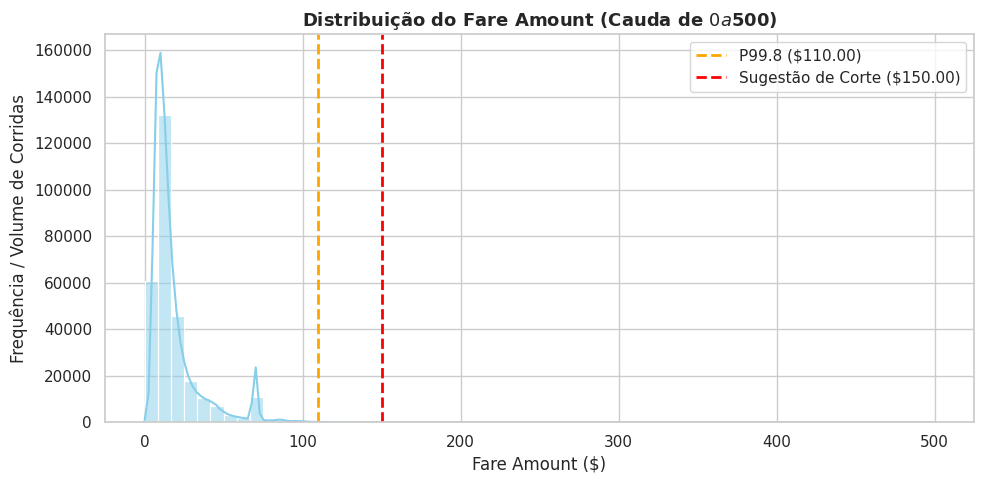

In [117]:
# 1. Filtrando uma amostra do PySpark para não sobrecarregar a memória
df_hist_sample = df.filter((F.col("fare_amount") > 0) & (F.col("fare_amount") <= 500)) \
                   .select("fare_amount") \
                   .sample(withReplacement=False, fraction=0.1, seed=42) \
                   .toPandas()

# 2. Plot do Histograma
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

sns.histplot(df_hist_sample["fare_amount"], bins=60, kde=True, color="skyblue")

# Linhas de referência baseadas na sua análise de percentis
plt.axvline(110.00, color="orange", linestyle="--", linewidth=2, label="P99.8 ($110.00)")
plt.axvline(150.00, color="red", linestyle="--", linewidth=2, label="Sugestão de Corte ($150.00)")

plt.title("Distribuição do Fare Amount (Cauda de $0 a $500)", fontsize=13, fontweight="bold")
plt.xlabel("Fare Amount ($)")
plt.ylabel("Frequência / Volume de Corridas")
plt.legend()
plt.tight_layout()
plt.show()

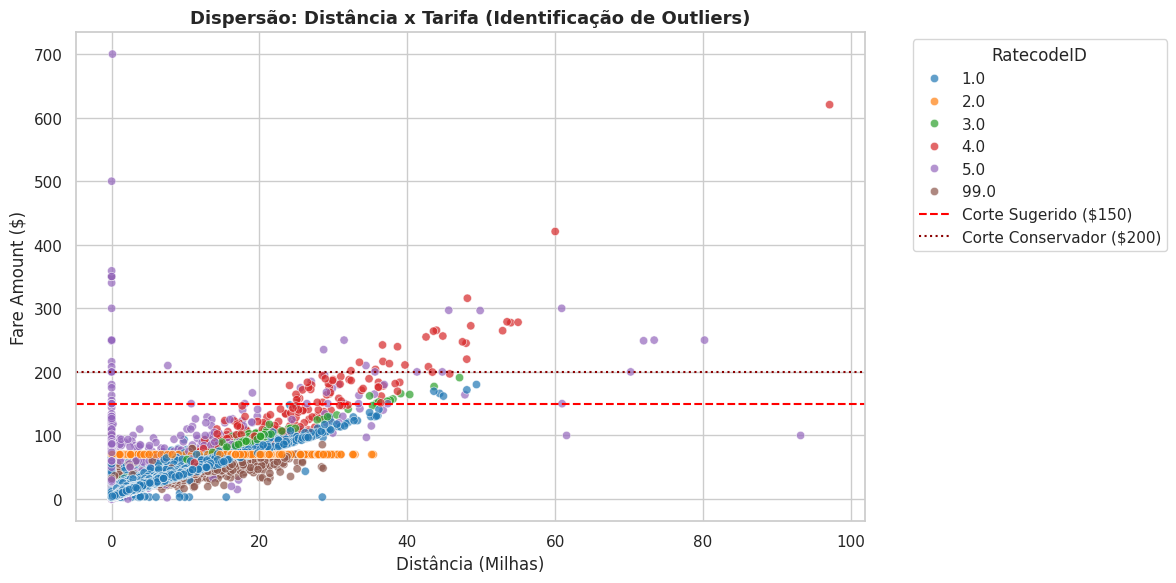

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Amostragem no PySpark incluindo a distância e a tarifa (RatecodeID)
df_scatter_sample = df.filter((F.col("fare_amount") > 0) & (F.col("fare_amount") <= 1000)) \
                      .select("trip_distance", "fare_amount", "RatecodeID") \
                      .sample(withReplacement=False, fraction=0.05, seed=42) \
                      .toPandas()

# 2. Plot do Scatter Plot
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_scatter_sample,
    x="trip_distance",
    y="fare_amount",
    hue="RatecodeID",
    palette="tab10",
    alpha=0.7
)

# Linhas horizontais de corte de segurança
plt.axhline(150.00, color="red", linestyle="--", linewidth=1.5, label="Corte Sugerido ($150)")
plt.axhline(200.00, color="darkred", linestyle=":", linewidth=1.5, label="Corte Conservador ($200)")

plt.title("Dispersão: Distância x Tarifa (Identificação de Outliers)", fontsize=13, fontweight="bold")
plt.xlabel("Distância (Milhas)")
plt.ylabel("Fare Amount ($)")
plt.legend(title="RatecodeID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Com base na análise temos que decidir se utilizamos o corte em 500 assegurando boa parte das viagens interestaduais com RatecodeID 4/5 ou um pouco mais abaixo(200 ou 150) para tentar normalizar mais a distribuição e manter apenas a escala de mobilidade metropolitana diária de NYC (viagens normais de passageiros).

**obs:** percebemos que o maior problema de inconsistencia é o trip_distance = 0, o tratamento dessa distancia irá tratar as principais inconsistencia, restando só os outliers estatíscos/artificiais.

**- Extra**

No dicionário oficial de dados do Taxi & Limousine Commission de NYC, a coluna extra armazena apenas as sobretaxas/adicionais de horário cobradas no taxímetro.

Não é uma taxa genérica, nem gorjeta ou pedágio. Ela engloba estritamente duas taxas regulamentadas por lei em NYC:

**Rush Hour Surcharge** (Sobretaxa de Horário de Pico):

* Valor: $2.50

* Regra: Aplicada de segunda a sexta-feira, das 16h às 20h.

**Overnight Surcharge** (Sobretaxa Noturna):

* Valor: $1.00

* Regra: Aplicada todos os dias, das 20h às 06h.

**Outros horários** (Fora de pico / Diurno):

* Valor: $0.00

**obs1:** Valores negativos vão ser tratados como todos os outros valoroes monetários negativos, exclusão.

**obs2:** Outros valores, podem representar acumulos de outras taxas.

In [119]:
# Checando os valores mais comuns na coluna extra
df.groupBy("extra")\
.count()\
.orderBy(F.desc("count"))\
.show(35)

+-----+-------+
|extra|  count|
+-----+-------+
|  0.0|1290548|
|  2.5| 705767|
|  1.0| 526527|
|  5.0| 192426|
|  3.5| 143201|
|  6.0|  23477|
|  7.5|  22407|
| 9.25|  10506|
| -1.0|  10287|
| 4.25|   9767|
| 1.75|   5871|
| -2.5|   5564|
| 6.75|   4188|
| 2.75|   3328|
|10.25|   2911|
|11.75|   2440|
| 7.75|   2373|
| -5.0|   1146|
| 10.0|    642|
|  8.5|    394|
| -6.0|    319|
| -7.5|    227|
|  2.0|    160|
|  3.2|     45|
|  0.5|     28|
| 5.25|     16|
| 3.25|     15|
|  7.0|      7|
| 0.75|      5|
|  1.5|      4|
| 0.02|      3|
| 0.06|      3|
| -1.5|      3|
|14.25|      2|
| 0.25|      2|
+-----+-------+
only showing top 35 rows


In [120]:
df_ano = df.filter(F.col("extra") < 0)
print(df_ano.count())
print((df_ano.count()/df.count())*100)

17548
0.59191317347495


Os Anômalos e Estornos
Valores Negativos (-1.0, -2.5, -5.0): Novamente, são os espelhos exatos dos cancelamentos e estornos da frota.

Valores Quebrados Estranhos (4.25, 6.75, 11.75): Lançamentos administrativos ou combinação de múltiplas sobretaxas de viagem interestadual.

**Conclusão:** Podemos considerar o corte extra >= 0

**- tip_amount**

O taxímetro REGISTRA APENAS gorjetas pagas no Cartão de Crédito (payment_type = 1).

Quando o passageiro paga em dinheiro (payment_type = 2), a gorjeta é dada direto na mão do motorista. Portanto, **por hipótese** o sistema registraria tip_amount = 0.0 para 100% das corridas em dinheiro, mesmo que o passageiro tenha deixado uma gorjeta generosa.

**obs1:** Valores negativos vão ser tratados como todos os outros valoroes monetários negativos, exclusão.

In [121]:
# Média e máximo de gorjeta por tipo de pagamento
df.groupBy("payment_type") \
  .agg(
      F.count("*").alias("total_corridas"),
      F.round(F.avg("tip_amount"), 2).alias("media_gorjeta"),
      F.round(F.max("tip_amount"), 2).alias("max_gorjeta"),
      F.sum(F.when(F.col("tip_amount") > 0, 1).otherwise(0)).alias("qtd_com_gorjeta")
  ) \
  .orderBy("payment_type") \
  .show()

+------------+--------------+-------------+-----------+---------------+
|payment_type|total_corridas|media_gorjeta|max_gorjeta|qtd_com_gorjeta|
+------------+--------------+-------------+-----------+---------------+
|           0|        140162|         1.55|       40.0|          48799|
|           1|       2319046|         4.17|      428.0|        2204834|
|           2|        439191|          0.0|     141.49|            128|
|           3|         19597|         0.01|      24.41|             99|
|           4|         46628|         0.04|       50.8|            370|
+------------+--------------+-------------+-----------+---------------+



In [122]:
# 1. Gorjetas Negativas
print("--- GORJETAS NEGATIVAS ---")
df.filter(F.col("tip_amount") < 0) \
  .select("fare_amount", "tip_amount", "payment_type", "VendorID") \
  .show(15)

--- GORJETAS NEGATIVAS ---
+-----------+----------+------------+--------+
|fare_amount|tip_amount|payment_type|VendorID|
+-----------+----------+------------+--------+
|      -35.9|     -8.18|           1|       2|
|      -56.2|    -22.24|           3|       2|
|      -70.0|    -16.19|           1|       2|
|       -3.0|     -0.01|           3|       2|
|       -3.0|     -0.01|           3|       2|
|       -3.0|     -0.01|           3|       2|
|       -3.0|     -0.01|           3|       2|
|       -3.0|     -2.85|           1|       2|
|       -3.0|     -0.01|           3|       2|
|       -3.0|     -0.01|           3|       2|
|       -3.0|     -0.01|           3|       2|
|       -3.7|     -1.54|           3|       2|
|       -3.0|     -0.01|           3|       2|
|       -3.0|     -0.01|           3|       2|
|       -3.0|     -0.01|           3|       2|
+-----------+----------+------------+--------+
only showing top 15 rows


**Análise de outlires das gorjetas**

In [123]:
# 2. Gorjetas Absurdas / Outliers de Topo
print("--- GORJETAS ACIMA DE $100 ---")
df.filter(F.col("tip_amount") > 100) \
  .select("trip_distance", "fare_amount", "tip_amount", "payment_type", "RatecodeID") \
  .orderBy(F.desc("tip_amount")) \
  .show(30)

--- GORJETAS ACIMA DE $100 ---
+-------------+-----------+----------+------------+----------+
|trip_distance|fare_amount|tip_amount|payment_type|RatecodeID|
+-------------+-----------+----------+------------+----------+
|          0.0|       0.01|     428.0|           1|         5|
|         4.21|       22.6|     422.7|           1|         1|
|         3.92|       17.7|     303.0|           1|         1|
|         47.1|      281.6|     300.0|           1|         4|
|          0.0|        3.0|     280.0|           1|         1|
|        15.38|       70.0|     250.0|           1|         2|
|         2.34|       22.6|    220.88|           1|         1|
|          2.4|       17.0|     202.0|           1|         1|
|         0.84|        8.6|     202.0|           1|         1|
|          0.8|        8.6|    175.17|           1|         1|
|          0.0|        3.0|     150.0|           1|         1|
|          3.1|        0.0|     144.0|           1|         5|
|       110.46|     -669

In [124]:
#gorjeta menor que o total (sanidade), cartão, sem negativo

base = df.filter(
    (F.col("tip_amount") >= 0) &
    (F.col("tip_amount") < F.col("total_amount"))
)

#quartis de tip_amount (valor bruto)
q = base.approxQuantile("tip_amount", [0.25, 0.50, 0.75], 0.001)
q1, med, q3 = q
iqr = q3 - q1
lim_15 = q3 + 1.5 * iqr
lim_30 = q3 + 3.0 * iqr

print("=== tip_amount (valor bruto) ===")
print(f"Q1={q1:.2f}  mediana={med:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}")
print(f"limiar 1.5·IQR={lim_15:.2f}   limiar 3·IQR={lim_30:.2f}\n")

#razão tip/fare (ex: $90 tip em corrida de $3)
com_razao = base.filter(F.col("fare_amount") > 0) \
                .withColumn("tip_ratio", F.col("tip_amount") / F.col("fare_amount"))

qr = com_razao.approxQuantile("tip_ratio", [0.25, 0.50, 0.75], 0.001)
qr1, medr, qr3 = qr
iqrr = qr3 - qr1
limr_15 = qr3 + 1.5 * iqrr
limr_30 = qr3 + 3.0 * iqrr

print("=== tip_ratio (tip / fare) ===")
print(f"Q1={qr1:.3f}  mediana={medr:.3f}  Q3={qr3:.3f}  IQR={iqrr:.3f}")
print(f"limiar 1.5·IQR={limr_15:.3f}   limiar 3·IQR={limr_30:.3f}\n")

#tips candidatas a fraude, por serem desproporcionais à tarifa
#razão acima do corte extremo (3·IQR)
fraudes = com_razao.filter(F.col("tip_ratio") > F.lit(limr_30))
print("registros com tip_ratio acima de 3·IQR:", fraudes.count())

(fraudes
 .select("tip_amount", "fare_amount", "tip_ratio", "total_amount",
         "trip_distance", "RatecodeID", "payment_type", "VendorID",
         "tpep_pickup_datetime", "PULocationID", "DOLocationID")
 .orderBy(F.col("tip_ratio").desc())
 .show(20, truncate=False))

=== tip_amount (valor bruto) ===
Q1=1.00  mediana=2.73  Q3=4.14  IQR=3.14
limiar 1.5·IQR=8.85   limiar 3·IQR=13.56

=== tip_ratio (tip / fare) ===
Q1=0.075  mediana=0.242  Q3=0.295  IQR=0.220
limiar 1.5·IQR=0.624   limiar 3·IQR=0.954

registros com tip_ratio acima de 3·IQR: 4492
+----------+-----------+------------------+------------+-------------+----------+------------+--------+--------------------+------------+------------+
|tip_amount|fare_amount|tip_ratio         |total_amount|trip_distance|RatecodeID|payment_type|VendorID|tpep_pickup_datetime|PULocationID|DOLocationID|
+----------+-----------+------------------+------------+-------------+----------+------------+--------+--------------------+------------+------------+
|428.0     |0.01       |42800.0           |429.01      |0.0          |5         |1           |1       |2024-01-29 13:30:58 |265         |265         |
|140.0     |0.01       |14000.0           |163.33      |12.4         |5         |1           |1       |2024-01-25 08

É possível notar um comportamento estranho entre os valores de gorjeta em relação à tarifa. Por padrão de comportamento, gorjetas em geral assumem valores próximos ou inferiores à tarifa da corrida. Em muitos casos a gorjeta é selecionada no aplicativo por botões de percentual (10%, 25%, 50%) para facilitar ao cliente. Logo, gorjetas que superam em muito o valor da corrida tendem a ser outliers artificiais (erro humano ou sistemático), e não gorjetas legítimas.

Para investigar, avaliamos o comportamento das gorjetas cujo valor supera **3× a tarifa** (`fare_amount`), utilizando a razão `tip_amount / fare_amount` como métrica — mais robusta que o valor absoluto, pois uma gorjeta alta em uma corrida cara pode ser legítima, enquanto o mesmo valor em uma corrida barata é implausível.

**Achado principal:** ao inspecionar os registros com razão extrema (acima de `Q3 + 3·IQR`), constatou-se que o problema **não reside na coluna `tip_amount` em si**, mas em corridas estruturalmente inválidas cujo valor foi lançado na gorjeta. Esses registros compartilham um padrão consistente:

- `trip_distance == 0` na quase totalidade dos casos (corridas sem trajeto real);
- `fare_amount` preenchido com valores simbólicos e artificiais — predominantemente `0.01` (tarifa vazia) ou `3.00` (bandeirada mínima), nenhum correspondente a uma tarifa medida por taxímetro;
- `PULocationID == DOLocationID` (origem e destino na mesma zona);
- `RatecodeID == 5` (tarifa negociada) na maior parte dos registros de `fare_amount == 0.01`.

Esse conjunto de características indica corridas de **tarifa negociada fora do taxímetro**, em que o valor combinado foi registrado em `tip_amount` em vez de `fare_amount`, com a tarifa preenchida por um valor de preenchimento. O caso mais extremo observado ilustra o padrão: `fare_amount = 0.01`, `tip_amount = 428.00` e `total_amount = 429.01` — ou seja, o `total_amount` está internamente coerente com a soma das parcelas; o defeito é de **alocação entre colunas**, não de valor total.

**Conclusão:** a coluna `tip_amount`, condicionada a corridas com trajeto real, não apresenta corrupção intrínseca que justifique exclusão própria. Os valores extremos de gorjeta são herdados de registros já cobertos pelas regras de `trip_distance == 0` (Seção 10.3). Dessa forma, evita-se um corte arbitrário por valor de gorjeta (que removeria valores legítimos) e trata-se a causa real — a invalidez da corrida — na seção correspondente, sem dupla contagem.

In [125]:
print("--- GORJETAS ACIMA DE 3x(fare_amount) ---")
df.filter(F.col("tip_amount") > 3*F.col("fare_amount")) \
  .select("trip_distance", "fare_amount", "tip_amount", "payment_type", "RatecodeID") \
  .orderBy(F.desc("tip_amount")) \
  .count()

--- GORJETAS ACIMA DE 3x(fare_amount) ---


38276

In [126]:
df.filter(F.col("tip_amount") < 0) \
  .count()

102

**Explorando tolls_amount:**

Exploração e entendomento da coluna ``tolls_amount``

In [127]:
# Checando estatísticas básicas dos pedágios
df.select(
    F.count("*").alias("total_corridas"),
    F.sum(F.when(F.col("tolls_amount") == 0, 1).otherwise(0)).alias("qtd_sem_pedagio"),
    F.sum(F.when(F.col("tolls_amount") > 0, 1).otherwise(0)).alias("qtd_com_pedagio"),
    F.sum(F.when(F.col("tolls_amount") < 0, 1).otherwise(0)).alias("qtd_negativos"),
    F.round(F.max("tolls_amount"), 2).alias("max_pedagio")
).show()

+--------------+---------------+---------------+-------------+-----------+
|total_corridas|qtd_sem_pedagio|qtd_com_pedagio|qtd_negativos|max_pedagio|
+--------------+---------------+---------------+-------------+-----------+
|       2964624|        2753809|         208780|         2035|     115.92|
+--------------+---------------+---------------+-------------+-----------+



A esmagadora maioria não paga pedágio: ~2.75 milhões de corridas (92.9%) têm tolls_amount = 0.0. Faz total sentido, já que a maioria circula apenas dentro de Manhattan ou dentro de um mesmo borough.

Corridas com Pedágio: ~208 mil corridas (7%) pagaram pedágio de forma legítima.

Negativos: Apensas 2.035 linhas (relacionadas aos estornos do Vendor 2).

Valor Máximo: $115.92.

In [128]:
# Verificando as maiores cobranças de pedágio
df.filter(F.col("tolls_amount") > 50) \
  .select("trip_distance", "fare_amount", "tolls_amount", "RatecodeID", "PULocationID", "DOLocationID") \
  .orderBy(F.desc("tolls_amount")) \
  .show(25)

+-------------+-----------+------------+----------+------------+------------+
|trip_distance|fare_amount|tolls_amount|RatecodeID|PULocationID|DOLocationID|
+-------------+-----------+------------+----------+------------+------------+
|        24.07|      178.7|      115.92|         4|         265|         265|
|        23.54|       70.0|      101.69|         2|         132|         265|
|          0.0|        5.8|        99.0|         1|         132|         132|
|        17.31|       86.7|       95.46|         3|         161|           1|
|         97.5|      353.7|        90.0|         1|         264|         265|
|         3.35|       18.4|        87.0|         1|         233|         142|
|         53.5|      200.4|        85.0|         1|          83|         265|
|         50.4|      184.3|        85.0|         1|         265|          83|
|          0.0|        3.0|        83.0|         1|         151|         151|
|         6.13|       31.7|        83.0|         1|          50|

Corridas rodoviárias longas saindo de NYC em direção a New Jersey, Connecticut ou condados distantes. Passar por múltiplas pontes/túneis de ida e volta pode acumular `$80.00` à `$115.00` em pedágios de forma 100% real.

inconsistencias: Este é um padrão idêntico ao que vimos na gorjeta! Corridas canceladas ou testes de terminal onde foi lançado um valor fixo de pedágio de $80+ em viagens de 0 milhas.

**Conclusão:** Exclusão dos negativos. A comporação multivariada revela que os tratamentos esperados das outras colunas vão servir para eliminar as inconsistencias dos pedagios(exemplo: trip_distance > 0)

**Análise de registros fora do domínio - colunas de valor fixo ("mta_tax", "improvement_surcharge", "congestion_surcharge", "Airport_fee")**

In [129]:
pos = df.filter(F.col("total_amount") >= 0)

colunas_monetarias = ["fare_amount", "extra", "mta_tax", "tip_amount",
                       "tolls_amount", "improvement_surcharge", "congestion_surcharge", "Airport_fee"]

dominios_validos = {
    "mta_tax": [0.0, 0.5],
    "improvement_surcharge": [0.0, 1.0],
    "congestion_surcharge": [0.0, 2.5],
    "Airport_fee": [0.0, 1.75],
}

for col, validos in dominios_validos.items():
    print(f"\n=== {col} — fora do domínio esperado {validos} (apenas positivos) ===")
    fora_dominio = pos.filter(~F.col(col).isin(validos))
    total_fora = fora_dominio.count()
    print(f"Linhas fora do domínio: {total_fora}")

    if total_fora > 0:
        fora_dominio.groupBy(col).count().orderBy(F.desc("count")).show(20)


=== mta_tax — fora do domínio esperado [0.0, 0.5] (apenas positivos) ===
Linhas fora do domínio: 9
+-------+-----+
|mta_tax|count|
+-------+-----+
|    4.0|    5|
|    1.4|    1|
|    0.8|    1|
|    1.6|    1|
|    3.0|    1|
+-------+-----+


=== improvement_surcharge — fora do domínio esperado [0.0, 1.0] (apenas positivos) ===
Linhas fora do domínio: 574
+---------------------+-----+
|improvement_surcharge|count|
+---------------------+-----+
|                  0.3|  574|
+---------------------+-----+


=== congestion_surcharge — fora do domínio esperado [0.0, 2.5] (apenas positivos) ===
Linhas fora do domínio: 5
+--------------------+-----+
|congestion_surcharge|count|
+--------------------+-----+
|                0.75|    3|
|                 1.0|    2|
+--------------------+-----+


=== Airport_fee — fora do domínio esperado [0.0, 1.75] (apenas positivos) ===
Linhas fora do domínio: 0


### **9.2.3. Linhas com total_amount não_negativo e algum registro monetário negativo**

In [130]:
pos = df.filter(F.col("total_amount") >= 0)

colunas_monetarias = ["fare_amount", "extra", "mta_tax", "tip_amount",
                       "tolls_amount", "improvement_surcharge", "congestion_surcharge", "Airport_fee"]

# Condição: qualquer uma das colunas monetárias (exceto total_amount) sendo negativa
condicao_alguma_negativa = None
for col in colunas_monetarias:
    cond = F.col(col) < 0
    condicao_alguma_negativa = cond if condicao_alguma_negativa is None else (condicao_alguma_negativa | cond)

inconsistentes = pos.filter(condicao_alguma_negativa)

print(f"Linhas com total_amount positivo e alguma coluna monetária negativa: {inconsistentes.count()}")

Linhas com total_amount positivo e alguma coluna monetária negativa: 2074


In [131]:
for col in colunas_monetarias:
    qtd = pos.filter(F.col(col) < 0).count()
    print(f"{col} negativo (com total_amount positivo): {qtd}")

fare_amount negativo (com total_amount positivo): 2064
extra negativo (com total_amount positivo): 10
mta_tax negativo (com total_amount positivo): 0
tip_amount negativo (com total_amount positivo): 0
tolls_amount negativo (com total_amount positivo): 0
improvement_surcharge negativo (com total_amount positivo): 0
congestion_surcharge negativo (com total_amount positivo): 0
Airport_fee negativo (com total_amount positivo): 0


**Resultado:** das oito colunas monetárias, apenas duas apresentam
valores negativos em corridas com `total_amount` positivo — as demais
seis estão completamente livres dessa inconsistência.

| Coluna | Ocorrências |
|---|---|
| `fare_amount` | 2.064 |
| `extra` | 10 |
| `mta_tax` | 0 |
| `tip_amount` | 0 |
| `tolls_amount` | 0 |
| `improvement_surcharge` | 0 |
| `congestion_surcharge` | 0 |
| `Airport_fee` | 0 |

A soma (2.064 + 10 = 2.074) bate exatamente com a contagem geral da
célula anterior, confirmando que nenhuma linha tem mais de uma coluna
monetária negativa simultaneamente.

`extra` negativo (10 linhas) tem volume desprezível — não justifica
investigação de causa sistemática, e é candidato a tratamento pontual
como valor inválido. O restante desta seção investiga `fare_amount`
negativo (2.064 linhas), que concentra o problema.

**Investigação — fare_amount negativo**

In [132]:
df.filter((F.col("fare_amount") < 0) & (F.col("total_amount") >= 0)).groupBy().count()

DataFrame[count: bigint]

In [133]:
fare_neg = df.filter((F.col("fare_amount") < 0) & (F.col("total_amount") >= 0))

# Testar se essas linhas são exatamente o subconjunto de total_diff == 2.5
fare_neg_com_diff = fare_neg.withColumn(
    "calculated_total",
    F.coalesce(F.col("fare_amount"), F.lit(0)) + F.coalesce(F.col("extra"), F.lit(0)) +
    F.coalesce(F.col("mta_tax"), F.lit(0)) + F.coalesce(F.col("tip_amount"), F.lit(0)) +
    F.coalesce(F.col("tolls_amount"), F.lit(0)) + F.coalesce(F.col("improvement_surcharge"), F.lit(0)) +
    F.coalesce(F.col("congestion_surcharge"), F.lit(0)) + F.coalesce(F.col("Airport_fee"), F.lit(0))
).withColumn(
    "total_diff", F.round(F.col("total_amount") - F.col("calculated_total"), 2)
)

fare_neg_com_diff.groupBy("total_diff").count().orderBy(F.desc("count")).show(10)

+----------+-----+
|total_diff|count|
+----------+-----+
|       2.5| 2016|
|       0.0|   48|
+----------+-----+



In [134]:
colunas_monetarias = ["fare_amount", "extra", "mta_tax", "tip_amount",
                       "tolls_amount", "improvement_surcharge", "congestion_surcharge", "Airport_fee"]

pos = df.filter(F.col("total_amount") >= 0)

condicao_alguma_negativa = None
for col in colunas_monetarias:
    cond = F.col(col) < 0
    condicao_alguma_negativa = cond if condicao_alguma_negativa is None else (condicao_alguma_negativa | cond)

inconsistentes = pos.filter(condicao_alguma_negativa)

soma_componentes = sum(F.coalesce(F.col(c), F.lit(0)) for c in colunas_monetarias)

inconsistentes_com_soma = inconsistentes.withColumn(
    "soma_calculada", F.round(soma_componentes, 2)
).withColumn(
    "bate", F.abs(F.col("total_amount") - F.col("soma_calculada")) < 0.02
)

total = inconsistentes_com_soma.count()
qtd_bate = inconsistentes_com_soma.filter(F.col("bate")).count()

print(f"Total de linhas (total_amount >= 0, alguma coluna monetária negativa): {total}")
print(f"Quantidade onde a soma bate com total_amount: {qtd_bate}")
print(f"Percentual: {qtd_bate / total * 100:.2f}%")

Total de linhas (total_amount >= 0, alguma coluna monetária negativa): 2074
Quantidade onde a soma bate com total_amount: 48
Percentual: 2.31%


**Resultado:** 2.016 linhas (97,7%) têm `total_diff = 2,5` — o mesmo
padrão já explicado pela ausência de `congestion_surcharge` na soma
(seção 9.2.1). As 48 restantes (2,3%) somam exatamente, sem
inconsistência. `fare_amount` negativo não é, portanto, um problema
novo — é uma consequência visível do mesmo mecanismo Flex Fare já
mapeado. Resta explicar por que o valor aparece negativo, e não
simplesmente ausente ou zerado.

**Hipótese 1 — fare_amount como resíduo (total menos taxas fixas)**

In [135]:
# Testar a hipótese: fare_amount = total_amount - mta_tax - improvement_surcharge (nos casos sem tolls)
flex_sem_tolls = df.filter(
    (F.col("payment_type") == 0) & (F.col("tolls_amount") == 0) & (F.col("extra") == 0)
)

flex_sem_tolls.withColumn(
    "fare_previsto",
    F.col("total_amount") - F.col("mta_tax") - F.col("improvement_surcharge")
).withColumn(
    "bate_hipotese",
    F.abs(F.col("fare_amount") - F.col("fare_previsto")) < 0.02
).groupBy("bate_hipotese").count().show()

+-------------+------+
|bate_hipotese| count|
+-------------+------+
|         true| 10167|
|        false|115811|
+-------------+------+



**Resultado:** apenas 10.167 de 125.978 linhas (8,1%) confirmam a
hipótese. Descartada como explicação principal.

**Hipótese 2 — resíduo incluindo tip_amount**

In [136]:
flex_sem_tolls = df.filter(
    (F.col("payment_type") == 0) & (F.col("tolls_amount") == 0) & (F.col("extra") == 0)
)

flex_sem_tolls.withColumn(
    "fare_previsto",
    F.col("total_amount") - F.col("mta_tax") - F.col("improvement_surcharge") - F.col("tip_amount")
).withColumn(
    "bate_hipotese_v2",
    F.abs(F.col("fare_amount") - F.col("fare_previsto")) < 0.02
).groupBy("bate_hipotese_v2").count().show()

+----------------+------+
|bate_hipotese_v2| count|
+----------------+------+
|            true| 12325|
|           false|113653|
+----------------+------+



**Resultado:** apenas 12.325 de 125.978 linhas (9,8%) confirmam a
hipótese — ganho marginal em relação à Hipótese 1. Também descartada.

**Conclusão — fare_amount negativo**

Testadas duas hipóteses de decomposição simples do preço no Flex Fare,
ambas descartadas por explicarem menos de 10% dos casos. A causa exata
de `fare_amount` aparecer negativo — em vez de simplesmente ausente ou
zerado — **permanece indeterminada**: o Flex Fare aparenta usar uma
lógica de precificação interna não documentada publicamente pela TLC,
não reconstruível a partir das colunas disponíveis no dataset.

**Decisão:** `total_amount` é mantido como valor confiável e
efetivamente cobrado. `fare_amount` é marcado como
inválido/não-decomponível para as 2.064 linhas afetadas — a corrida
permanece na fato, sem exclusão, apenas com o componente `fare_amount`
sinalizado como não-confiável.

```python
df = df.withColumn(
    "fare_amount_status",
    F.when(
        (F.col("fare_amount") < 0) & (F.col("total_amount") >= 0) & (F.col("payment_type") == 0),
        "invalido_causa_indeterminada"
    ).otherwise("valido")
)
```

`extra` negativo (10 linhas) segue o mesmo princípio — volume
desprezível, tratado como valor pontualmente inválido, sem
investigação de causa sistemática.

In [137]:
base_com_razao = df.filter(F.col("trip_distance") > 0).withColumn(
    "total_por_milha",
    F.col("total_amount") / F.col("trip_distance")
)

percentis = [0.1, 0.25, 0.5, 0.75, 0.9, 0.99]

flex_fare = base_com_razao.filter(F.col("payment_type") == 0)

flex_negativo = flex_fare.filter(F.col("fare_amount") < 0)
flex_positivo = flex_fare.filter(F.col("fare_amount") > 0)

print("Flex Fare, fare_amount < 0 (n = {}):".format(flex_negativo.count()))
print(flex_negativo.approxQuantile("total_por_milha", percentis, 0.0001))

print("\nFlex Fare, fare_amount > 0 (n = {}):".format(flex_positivo.count()))
print(flex_positivo.approxQuantile("total_por_milha", percentis, 0.0001))

Flex Fare, fare_amount < 0 (n = 2044):
[0.5464480874316939, 0.779296875, 1.1772151898734178, 1.8518518518518516, 2.912621359223301, 6.976744186046512]

Flex Fare, fare_amount > 0 (n = 115249):
[5.187739463601533, 6.792880258899676, 9.19047619047619, 12.595238095238097, 17.894117647058824, 43.61290322580645]


É possível observar a completa incompatibilidade das distribuições

### **9.2.4. Análise de registros negativos em total amount**

In [138]:
dups = df.groupBy(df.columns).count().filter(F.col("count") > 1)

dups.count()                              # quantos grupos duplicados existem
dups.orderBy(F.desc("count")).show(10)    # os casos mais repetidos
dups.agg(F.sum("count")).show()           # total de linhas envolvidas

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+-----------------+-----+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|trip_duration_min|count|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+-----------------+-----+
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+--

In [139]:
df.count() - df.dropDuplicates().count()   # deve dar 0

0

Não há registros em duplicidade considerando todas as colunas.

Vamos avaliar os dados negativos por grupo de cada variável categórica:

In [140]:
neg = df.filter(F.col("total_amount") < 0)

categoricas = ["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag"]

for col in categoricas:
    print(f"\n=== {col} ===")

    total_categoria = df.groupBy(col).count().withColumnRenamed("count", "total")
    neg_por_categoria = neg.groupBy(col).count().withColumnRenamed("count", "qtd_negativos")

    resultado = (total_categoria
        .join(neg_por_categoria, total_categoria[col].eqNullSafe(neg_por_categoria[col]), "left")
        .select(
            total_categoria[col],
            "total",
            F.coalesce(F.col("qtd_negativos"), F.lit(0)).alias("qtd_negativos")
        )
        .withColumn("pct_negativos_na_categoria", F.round(F.col("qtd_negativos") / F.col("total") * 100, 4))
        .orderBy(F.desc("pct_negativos_na_categoria")))

    resultado.show()


=== VendorID ===
+--------+-------+-------------+--------------------------+
|VendorID|  total|qtd_negativos|pct_negativos_na_categoria|
+--------+-------+-------------+--------------------------+
|       2|2234632|        35504|                    1.5888|
|       1| 729732|            0|                       0.0|
|       6|    260|            0|                       0.0|
+--------+-------+-------------+--------------------------+


=== RatecodeID ===
+----------+-------+-------------+--------------------------+
|RatecodeID|  total|qtd_negativos|pct_negativos_na_categoria|
+----------+-------+-------------+--------------------------+
|         6|      7|            2|                   28.5714|
|         3|   7954|          335|                    4.2117|
|         5|  19410|          721|                    3.7146|
|         4|   6365|          220|                    3.4564|
|         2|  98713|         2048|                    2.0747|
|         1|2663350|        32176|           

A partir disso pudemos aferir a presença de 35504 registros negativos com incidência única e exclusivamente no VendorID "2 = Curb Mobility, LLC". É possível também identificar uma clara maior incidência destes registros entre os payment_type: 3 = No charge e 4 = Dispute. Devido a este perfil, a hipótese de que tais registros representam reembolsos foi levantada.

Para investigar tal possibilidade investigaremos a existência de linhas duplicatas associadas aos registros negativos (considerando iguais as colunas não-monetárias e de sinal inverso as colunas monetárias).

In [141]:
chave = ["VendorID", "tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count", "trip_distance", "RatecodeID", "store_and_fwd_flag", "PULocationID", "DOLocationID", "payment_type"]

grupos = df.groupBy(chave).count().filter(F.col("count") > 1)
grupos.cache()

print(f"Grupos com mais de uma ocorrência: {grupos.count()}")
print(chave)
grupos.groupBy("count").count().orderBy("count").show()

Grupos com mais de uma ocorrência: 31097
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type']
+-----+-----+
|count|count|
+-----+-----+
|    2|31097|
+-----+-----+



Quantas destas duplicatas apresentam valor idêntico com sinal invertido nas colunas monetárias?

In [142]:
nao_monetarias = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID",
                   "VendorID", "passenger_count", "trip_distance", "RatecodeID",
                   "store_and_fwd_flag", "payment_type"]

monetarias = ["fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
              "improvement_surcharge", "total_amount", "congestion_surcharge", "Airport_fee"]

neg = df.filter(F.col("total_amount") < 0)
pos = df.filter(F.col("total_amount") >= 0)

# Inverte o sinal das monetárias do lado negativo
neg_invertido = neg.select(
    *nao_monetarias,
    *[(-F.col(c)).alias(c) for c in monetarias]
)

# Junção exigindo: não-monetárias idênticas + monetárias (já invertidas) idênticas
pares_exatos = neg_invertido.join(pos, on=nao_monetarias + monetarias, how="inner")

print(f"Duplicatas com não-monetárias idênticas e monetárias exatamente invertidas (número de pares): {pares_exatos.count()}")

Duplicatas com não-monetárias idênticas e monetárias exatamente invertidas (número de pares): 30669


Ou seja, há um forte indício de que estas 30669 linhas com colunas monetárias negativas são reembolsos


No entanto, ainda restam 4835 (35504 - 30669) registros negativos sem explicação. Vamos analisar quantos deles possuem duplicadas apenas considerando as colunas referentes a lugar e tempo ("tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID")

In [143]:
nao_monetarias = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID",
                   "VendorID", "passenger_count", "trip_distance", "RatecodeID",
                   "store_and_fwd_flag", "payment_type"]

monetarias = ["fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
              "improvement_surcharge", "total_amount", "congestion_surcharge", "Airport_fee"]

neg = df.filter(F.col("total_amount") < 0)
pos = df.filter(F.col("total_amount") >= 0)

# Reconstituindo os 4.835 remanescentes (negativos sem par exato pela chave completa)
neg_invertido = neg.select(*nao_monetarias, *[(-F.col(c)).alias(c) for c in monetarias])
pares_exatos_invertido = neg_invertido.join(pos, on=nao_monetarias + monetarias, how="inner")

remanescentes_invertido = neg_invertido.join(
    pares_exatos_invertido.select(*nao_monetarias, *monetarias),
    on=nao_monetarias + monetarias,
    how="left_anti"
)

# Volta ao sinal original (negativo)
remanescentes = remanescentes_invertido.select(*nao_monetarias, *[(-F.col(c)).alias(c) for c in monetarias])

print(f"Remanescentes (negativos sem par exato): {remanescentes.count()}")

# Agora: desses remanescentes, quantos têm alguma correspondência positiva usando SÓ tempo+lugar
chave_4 = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID"]

remanescentes_com_par_frouxo = remanescentes.join(
    pos.select(*chave_4).distinct(),
    on=chave_4,
    how="inner"
)

print(f"Desses remanescentes, quantos têm correspondência positiva por tempo+lugar: {remanescentes_com_par_frouxo.count()}")
print(f"Remanescentes sem correspondência nem por tempo+lugar: {remanescentes.count() - remanescentes_com_par_frouxo.count()}")

Remanescentes (negativos sem par exato): 4835
Desses remanescentes, quantos têm correspondência positiva por tempo+lugar: 432
Remanescentes sem correspondência nem por tempo+lugar: 4403


Uma das hipóteses referentes a estes registros é de que representem reembolsos referentes a corridas ocorridas no mês anterior (dezembro/2023), o que motiva uma investigação.

In [144]:


url_dez_2023 = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-12.parquet"
destino_dez = Path("data/yellow_tripdata_2023-12.parquet")
destino_dez.parent.mkdir(parents=True, exist_ok=True)

if not destino_dez.exists():
    urllib.request.urlretrieve(url_dez_2023, destino_dez)

df_dez_2023 = spark.read.parquet(str(destino_dez))

print(f"Linhas em dezembro/2023: {df_dez_2023.count()}")

Linhas em dezembro/2023: 3376567


In [145]:
chave_4 = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID"]

neg = df.filter(F.col("total_amount") < 0)
pos = df.filter(F.col("total_amount") >= 0)

# Órfãos mesmo sob a chave mais frouxa (tempo + zona)
neg_com_par_frouxo = neg.join(pos.select(*chave_4).distinct(), on=chave_4, how="inner")
orfaos_totais = neg.join(neg_com_par_frouxo.select(*chave_4).distinct(), on=chave_4, how="left_anti")

print(f"Negativos órfãos mesmo com chave frouxa (tempo+zona): {orfaos_totais.count()}")

# Testar correspondência com dezembro/2023, usando a mesma chave frouxa
orfaos_em_dez = orfaos_totais.join(df_dez_2023.select(*chave_4).distinct(), on=chave_4, how="inner")

print(f"Desses órfãos, quantos têm correspondência em dezembro/2023 (mesma chave frouxa): {orfaos_em_dez.count()}")

Negativos órfãos mesmo com chave frouxa (tempo+zona): 4403
Desses órfãos, quantos têm correspondência em dezembro/2023 (mesma chave frouxa): 0


### Decisão: exclusão dos negativos órfãos

Dos 35.504 registros com `total_amount` negativo, 30.669 (86,4%)
possuem uma contraparte positiva idêntica nas colunas não-monetárias e
exatamente invertida nas colunas monetárias — o padrão de lançamento e
estorno já caracterizado nesta seção. Os 4.835 registros restantes
(13,6% dos negativos; 0,16% da base total) não apresentam
correspondência identificável sob nenhuma das definições de chave
testadas.

**Investigação realizada:**

- Correspondência exata em todas as 19 colunas — nenhuma encontrada.
- Correspondência exigindo igualdade nas 10 colunas não-monetárias e
  inversão exata nas 9 monetárias — nenhuma encontrada.
- Correspondência sob chave frouxa, considerando apenas tempo e
  localização (`tpep_pickup_datetime`, `tpep_dropoff_datetime`,
  `PULocationID`, `DOLocationID`), sem exigir igualdade em nenhum outro
  atributo — nenhuma encontrada.
- Correspondência com o arquivo de dezembro/2023, sob a hipótese de que
  o lançamento original estivesse fora do recorte de janeiro — nenhuma
  encontrada, sob qualquer uma das definições de chave acima.

**Hipóteses consideradas e não confirmáveis com os dados
disponíveis:** lançamento original não exportado pelo provedor;
correção simultânea de atributos operacionais no momento do estorno;
ajuste interno sem contraparte simples de lançamento. Nenhuma fonte
oficial da TLC documenta o mecanismo de estorno ou explica a origem
desses registros.

**Decisão:** os 4.835 registros foram **excluídos da tabela fato**,
sob o grão "uma linha = uma corrida" — como não há evidência de que
representem uma viagem capturada na base, sua permanência distorceria
contagens e métricas sem possibilidade de correção. Os registros
originais foram preservados integralmente na tabela de auditoria
`negativos_orfaos_causa_indeterminada`, garantindo rastreabilidade
total e possibilidade de revisão futura caso surja nova evidência.

**Materialidade:** o volume envolvido (0,16% da base) não compromete
a validade de nenhuma métrica agregada da fato final.

## **9.3. Análise de inconsitências em distância**

### **9.3.1. trip_distance - outliers**

In [146]:
df.approxQuantile("trip_distance", [0.5, 0.9, 0.99, 0.999, 0.9999, 1.0], 0.0001)

[1.68, 8.42, 20.0, 29.19, 312722.3, 312722.3]

Um valor de distância isolado não revela erro — só a relação com a duração revela. Cálculo da velocidade implícita, tratando divisão por zero.

In [147]:
df_vel = df.withColumn(
    "duracao_min",
    (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60
).withColumn(
    "velocidade_mph",
    F.when(F.col("duracao_min") > 0, F.col("trip_distance") / (F.col("duracao_min") / 60))
     .otherwise(None)
)

df_vel.approxQuantile("velocidade_mph", [0.9, 0.99, 0.999, 0.9999, 1.0], 0.0001)

[20.00271370420624,
 37.00682128240109,
 49.15862068965518,
 1443333.6923076923,
 1443333.6923076923]

**Critério para invalidação da distância — velocidade implícita:**

Para identificar erros de captura em `trip_distance`, calculamos a
**velocidade implícita** de cada corrida (distância dividida pela
duração) e comparamos com o limite legal máximo de velocidade em vias de
Nova York.

**Referência:** o limite de velocidade mais alto permitido no estado de
Nova York é de **65 mph**, vigente na New York State Thruway desde 1995
— o teto legal mais alto entre todas as vias do estado (New York State
Senate, Vehicle and Traffic Law).

Como nenhuma corrida pode legalmente sustentar, em média, velocidade
superior a esse limite, adotamos **80 mph** (Cerca de 130 km/h) como critério de
invalidação — um valor acima do teto legal com margem de segurança para
absorver imprecisões de arredondamento em timestamps, sem risco de
invalidar corridas legítimas.

In [148]:
df = df.withColumn(
    "average_speed_mph",
    F.when(F.col("trip_duration_min") > 0,
           F.col("trip_distance") / (F.col("trip_duration_min") / 60))
     .otherwise(None)
)

df_tratado = df.filter(
    (F.col("average_speed_mph").isNull()) | (F.col("average_speed_mph") <= 80)
)

print(f"Linhas antes: {df.count()}")
print(f"Linhas depois: {df_tratado.count()}")

df_tratado.orderBy(F.desc("trip_duration_min")).select(
    "trip_distance", "average_speed_mph", "trip_duration_min",
    "RatecodeID", "payment_type", "fare_amount", "total_amount"
).show(10, truncate=False)

Linhas antes: 2964624
Linhas depois: 2963516
+-------------+--------------------+-----------------+----------+------------+-----------+------------+
|trip_distance|average_speed_mph   |trip_duration_min|RatecodeID|payment_type|fare_amount|total_amount|
+-------------+--------------------+-----------------+----------+------------+-----------+------------+
|2.26         |0.014341011485500347|9455.4           |1         |2           |30.3       |36.8        |
|35.7         |0.5914235304837138  |3621.77          |3         |2           |150.4      |181.41      |
|31.95        |0.6171567649009394  |3106.18          |1         |2           |2221.3     |2225.3      |
|0.0          |0.0                 |2957.47          |1         |2           |3.0        |4.5         |
|0.2          |0.004194513576242275|2860.88          |1         |2           |28.9       |33.9        |
|0.0          |0.0                 |2585.8           |1         |2           |3.0        |4.5         |
|4.56         |0.11

In [149]:
# 1. Calcula a diferença de tempo em segundos e converte para horas
df_velocidade = df.withColumn(
    "duration_hours",
    (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 3600.0
)

# 2. Calcula a velocidade média (evitando divisão por zero com F.when)
df_velocidade = df_velocidade.withColumn(
    "avg_speed_mph",
    F.when(F.col("duration_hours") > 0, F.col("trip_distance") / F.col("duration_hours"))
     .otherwise(0.0)
)

In [150]:
print("Corridas com velocidades suspeitamente altas (Inconsistentes):")
df_velocidade.filter(F.col("avg_speed_mph") > 80) \
    .select("tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_distance", "duration_hours", "avg_speed_mph", "total_amount") \
    .orderBy(F.desc("avg_speed_mph")) \
    .show(10)

Corridas com velocidades suspeitamente altas (Inconsistentes):
+--------------------+---------------------+-------------+-------------------+------------------+------------+
|tpep_pickup_datetime|tpep_dropoff_datetime|trip_distance|     duration_hours|     avg_speed_mph|total_amount|
+--------------------+---------------------+-------------+-------------------+------------------+------------+
| 2024-01-30 06:37:00|  2024-01-30 06:50:00|     312722.3|0.21666666666666667|1443333.6923076923|       22.15|
| 2024-01-09 07:13:00|  2024-01-09 07:17:00|     59076.43|0.06666666666666667| 886146.4500000001|       23.17|
| 2024-01-21 11:58:00|  2024-01-21 12:12:00|     72975.97|0.23333333333333334|312754.15714285715|       20.04|
| 2024-01-12 05:16:00|  2024-01-12 05:26:00|     51619.36|0.16666666666666666|309716.16000000003|        24.2|
| 2024-01-11 07:41:00|  2024-01-11 07:48:00|     33934.01|0.11666666666666667| 290862.9428571429|        19.6|
| 2024-01-24 12:26:00|  2024-01-24 12:42:00|     

In [151]:
print("Corridas com distância mas sem velocidade (Duração negativa ou nula):")
df_velocidade.filter((F.col("trip_distance") > 0) & (F.col("avg_speed_mph") <= 0)) \
    .select("tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_distance", "avg_speed_mph") \
    .show(10)

Corridas com distância mas sem velocidade (Duração negativa ou nula):
+--------------------+---------------------+-------------+-------------+
|tpep_pickup_datetime|tpep_dropoff_datetime|trip_distance|avg_speed_mph|
+--------------------+---------------------+-------------+-------------+
| 2024-01-02 10:00:00|  2024-01-02 09:53:56|          7.2|          0.0|
| 2024-01-03 19:14:19|  2024-01-03 19:14:19|          1.2|          0.0|
| 2024-01-04 08:50:42|  2024-01-04 08:50:42|         19.3|          0.0|
| 2024-01-04 12:30:00|  2024-01-04 12:18:23|          4.8|          0.0|
| 2024-01-04 14:00:00|  2024-01-04 13:55:50|          5.6|          0.0|
| 2024-01-05 07:07:29|  2024-01-05 07:07:29|         0.31|          0.0|
| 2024-01-05 11:00:00|  2024-01-05 10:57:16|          0.6|          0.0|
| 2024-01-05 13:47:06|  2024-01-05 13:47:06|          5.5|          0.0|
| 2024-01-05 17:32:49|  2024-01-05 17:32:49|          0.6|          0.0|
| 2024-01-06 00:27:27|  2024-01-06 00:27:27|        27

In [152]:
# 1. Criar a coluna de faixas de velocidade (speed_range)
df_analise = df_velocidade.withColumn(
    "speed_range",
    F.when(F.col("avg_speed_mph") == 0, "00. 0 mph (Parado)")
     .when((F.col("avg_speed_mph") > 0) & (F.col("avg_speed_mph") <= 15), "01. 0 - 15 mph (Trânsito Pesado)")
     .when((F.col("avg_speed_mph") > 15) & (F.col("avg_speed_mph") <= 45), "02. 15 - 45 mph (Fluxo Normal)")
     .when((F.col("avg_speed_mph") > 45) & (F.col("avg_speed_mph") <= 80), "03. 45 - 80 mph (Rodovias/Aeroporto)")
     .otherwise("04. > 80 mph (Outliers/Erros)")
)

# 2. Agrupar e contar os registros
df_agrupado = df_analise.groupBy("speed_range").count()

# 3. Calcular o Total Geral usando Window Function e depois o Percentual
window_spec = Window.partitionBy()

df_com_percentual = df_agrupado.withColumn(
    "total_records",
    F.sum("count").over(window_spec)
).withColumn(
    "percentage",
    F.round((F.col("count") / F.col("total_records")) * 100, 2)
).drop("total_records") # Removemos a coluna auxiliar do total

# 4. Exibir o resultado ordenado pelas faixas
df_com_percentual.orderBy("speed_range").show(truncate=False)

+------------------------------------+-------+----------+
|speed_range                         |count  |percentage|
+------------------------------------+-------+----------+
|00. 0 mph (Parado)                  |60483  |2.04      |
|01. 0 - 15 mph (Trânsito Pesado)    |2363705|79.73     |
|02. 15 - 45 mph (Fluxo Normal)      |534215 |18.02     |
|03. 45 - 80 mph (Rodovias/Aeroporto)|5114   |0.17      |
|04. > 80 mph (Outliers/Erros)       |1107   |0.04      |
+------------------------------------+-------+----------+



### **9.3.2. trip_distance == 0**

O valor zero em `trip_distance` não representa um único fenômeno — a
mesma leitura pode ter três origens distintas:

1. **Tarifa fixa/negociada** — o taxímetro não mede distância nesse regime.
   Zero é o comportamento esperado, não um erro.
2. **Cancelamento** — duração muito curta, sugerindo que o passageiro
   desistiu logo após o embarque. O carro não chegou a se deslocar.
3. **Falha de captura** — duração real decorrida (viagem de vários
   minutos) e tarifa condizente com uma corrida normal, mas distância
   registrada como zero. Não há explicação de regime tarifário nem de
   cancelamento: é falha do sensor de medição, análoga (em direção
   oposta) ao problema de velocidade implícita impossível já tratado
   nesta seção.

Apenas o terceiro cenário constitui erro de qualidade de dado. Os dois
primeiros são zero legítimo, e tratá-los como erro descartaria
informação válida ou uma decisão de negócio distinta (contar ou não
cancelamentos como corrida).

**Regimes tarifários que dispensam medição por taxímetro**

Nem todo `RatecodeID` calcula a tarifa a partir da distância percorrida.
Investigar essa distinção é necessário para interpretar corretamente os
casos onde `trip_distance = 0` — em alguns regimes, isso é o
comportamento esperado; em outros, é sinal de falha de captura.

In [153]:
zonas = spark.read.csv("data/taxi_zone_lookup.csv", header=True, inferSchema=True)

df_com_zonas = (df
    .join(zonas.select(F.col("LocationID").alias("PULocationID"),
                        F.col("Zone").alias("PU_Zone"),
                        F.col("Borough").alias("PU_Borough")), "PULocationID")
    .join(zonas.select(F.col("LocationID").alias("DOLocationID"),
                        F.col("Zone").alias("DO_Zone"),
                        F.col("Borough").alias("DO_Borough")), "DOLocationID")
)

def pct_zero(condicao, nome):
    subset = df_com_zonas.filter(condicao)
    total = subset.count()
    zeros = subset.filter(F.col("trip_distance") == 0).count()
    pct = round(zeros / total * 100, 2) if total > 0 else None
    print(f"{nome}: total={total}, zeros={zeros}, %={pct}")

# Cenário 1
pct_zero(F.col("RatecodeID") == 5, "RatecodeID == 5 (Negotiated fare)")

# Cenário 2 — JFK <-> Manhattan, nas duas direções reais
cond_jfk_manhattan = (F.col("RatecodeID") == 2) & (
    ((F.col("PU_Zone") == "JFK Airport") & (F.col("DO_Borough") == "Manhattan")) |
    ((F.col("PU_Borough") == "Manhattan") & (F.col("DO_Zone") == "JFK Airport"))
)
pct_zero(cond_jfk_manhattan, "RatecodeID == 2, rota Manhattan<->JFK")

# Cenário 3
pct_zero(F.col("payment_type") == 0, "payment_type == 0 (Flex Fare)")

RatecodeID == 5 (Negotiated fare): total=19410, zeros=10210, %=52.6
RatecodeID == 2, rota Manhattan<->JFK: total=89458, zeros=105, %=0.12
payment_type == 0 (Flex Fare): total=140162, zeros=22825, %=16.28


**RatecodeID 5 — Negotiated fare (única exceção plena)**

Tarifa combinada entre motorista e passageiro antes da viagem, sem
taxímetro. TLC: *"the fare must be mutually agreed upon before the
trip may begin"*. 52,60% das corridas neste código têm
`trip_distance = 0` — maior concentração entre os regimes, condizente
com a regra. Única exceção com justificativa documental plena.

**RatecodeID 2 — JFK (exceção parcial, condicional à rota)**

Fixo (US$ 70,00) só entre Manhattan e JFK, em qualquer direção; fora
dessa rota, volta a ser medido pelo taxímetro. `trip_distance = 0` só
é esperado na rota Manhattan↔JFK — nas demais, é anômalo. Requer
cruzar `PULocationID`/`DOLocationID` com a tabela de zonas para
confirmar o borough; sem isso, a exceção não é aplicável de forma
automática. Sobre o valor-base fixo somam-se sobretaxas condicionais
(MTA State Surcharge, Improvement Surcharge, pico, Congestion
Surcharge, Congestion Pricing toll) — apenas `fare_amount` é fixo, o
`total_amount` permanece variável.

**Regimes que aparentam fixos, mas são medidos**

RatecodeID 3 (Newark): não é fixo — o taxímetro mede normalmente e o
valor final é dobrado a partir do limite da cidade.

RatecodeID 4 (Nassau/Westchester): também não é fixo — a regra exige
o taxímetro registrando durante toda a viagem, com a ressalva:
*"'double the meter' is NOT a flat rate"*.

Em ambos, `trip_distance = 0` não tem justificativa e é anômalo, como
no Standard rate.

**Flex Fare (`payment_type = 0`)**

Tarifa fechada via e-hail, fora do fluxo do taxímetro (`RatecodeID` e
`store_and_fwd_flag` nulos por natureza estrutural). Sem dispensa
documentada de medição — a taxa de `trip_distance = 0` (16,28%)
sugere falha de captura, não comportamento esperado.

**Síntese**

| Regime | Depende de taxímetro? | `trip_distance = 0` esperado? |
|---|---|---|
| Standard rate (1) | Sim | Não |
| JFK (2) | Só fora da rota Manhattan↔JFK | Só na rota Manhattan↔JFK |
| Newark (3) | Sim (valor dobrado) | Não |
| Nassau/Westchester (4) | Sim (valor dobrado) | Não |
| Negotiated fare (5) | Não | Sim |
| Group ride (6) | Não verificado (n=7) | — |
| Flex Fare | Sem dispensa documentada | Não — investigar como falha |

Fontes: Taxi Fare — TLC (https://www.nyc.gov/site/tlc/passengers/taxi-fare.page);
Código de Regras da TLC, §80-17; Industry Notice #22-02, TLC, dez/2022
(https://www.nyc.gov/assets/tlc/downloads/pdf/industry-notices/industry_notice_22_02_english.pdf)
(consultado em 18-23/07/2026)

In [154]:
zonas = spark.read.csv("data/taxi_zone_lookup.csv", header=True, inferSchema=True)

df_com_zonas = (df
    .join(zonas.select(F.col("LocationID").alias("PULocationID"),
                        F.col("Zone").alias("PU_Zone"),
                        F.col("Borough").alias("PU_Borough")), "PULocationID")
    .join(zonas.select(F.col("LocationID").alias("DOLocationID"),
                        F.col("Zone").alias("DO_Zone"),
                        F.col("Borough").alias("DO_Borough")), "DOLocationID")
)

# Filtra primeiro por trip_distance == 0
zero_total = df_com_zonas.filter(F.col("trip_distance") == 0)

# As três condições
cond_negociada = F.col("RatecodeID") == 5

cond_jfk_manhattan = (F.col("RatecodeID") == 2) & (
    ((F.col("PU_Zone") == "JFK Airport") & (F.col("DO_Borough") == "Manhattan")) |
    ((F.col("PU_Borough") == "Manhattan") & (F.col("DO_Zone") == "JFK Airport"))
)

cond_flex_fare = F.col("payment_type") == 0

condicoes_excluidas = cond_negociada | cond_jfk_manhattan | cond_flex_fare

# df2: só os zeros que NÃO caem em nenhuma das 3 condições
df2 = zero_total.filter(~condicoes_excluidas)

total_zero = zero_total.count()
total_df2 = df2.count()

print(f"Total de linhas com trip_distance == 0: {total_zero}")
print(f"Linhas com trip_distance == 0 excluindo as 3 condições (df2): {total_df2}")
print(f"Percentual do total de zeros que permanece fora das 3 condições: {total_df2 / total_zero * 100:.4f}%")

Total de linhas com trip_distance == 0: 60371
Linhas com trip_distance == 0 excluindo as 3 condições (df2): 27231
Percentual do total de zeros que permanece fora das 3 condições: 45.1061%


Vamos investigar dentre as linhas que não encaixam em nenhuma dessas 3 condições (RatecodeID == 5 (Negotiated fare), RatecodeID == 2 and rota Manhattan<->JFK, payment_type == 0 (Flex Fare)), quantas apresentam PULocation != DOLocation, circunstância inconsistente com trip_distance == 0.

In [155]:
total_df2 = df2.count()

pu_igual_do = df2.filter(F.col("PULocationID") == F.col("DOLocationID")).count()
pu_diferente_do = df2.filter(F.col("PULocationID") != F.col("DOLocationID")).count()

print(f"Total em df2: {total_df2}")
print(f"PULocationID == DOLocationID: {pu_igual_do} ({pu_igual_do / total_df2 * 100:.4f}%)")
print(f"PULocationID != DOLocationID: {pu_diferente_do} ({pu_diferente_do / total_df2 * 100:.4f}%)")

# Novo dataframe: apenas as linhas com PULocationID == DOLocationID
df3 = df2.filter(F.col("PULocationID") == F.col("DOLocationID"))

print(f"\nLinhas em df3 (PULocationID == DOLocationID): {df3.count()}")

Total em df2: 27231
PULocationID == DOLocationID: 15508 (56.9498%)
PULocationID != DOLocationID: 11723 (43.0502%)

Linhas em df3 (PULocationID == DOLocationID): 15508


Dentro do recorte de `trip_distance == 0` sem explicação de regime
(27.231 registros), **56,95%** (15.508) têm `PULocationID == DOLocationID`
— mesma zona de embarque e desembarque, compatível com cancelamento ou
corrida não iniciada. Os **43,05%** restantes (11.723) têm zonas
diferentes, indicando deslocamento real sem captura de distância —
padrão mais consistente com falha de sensor.

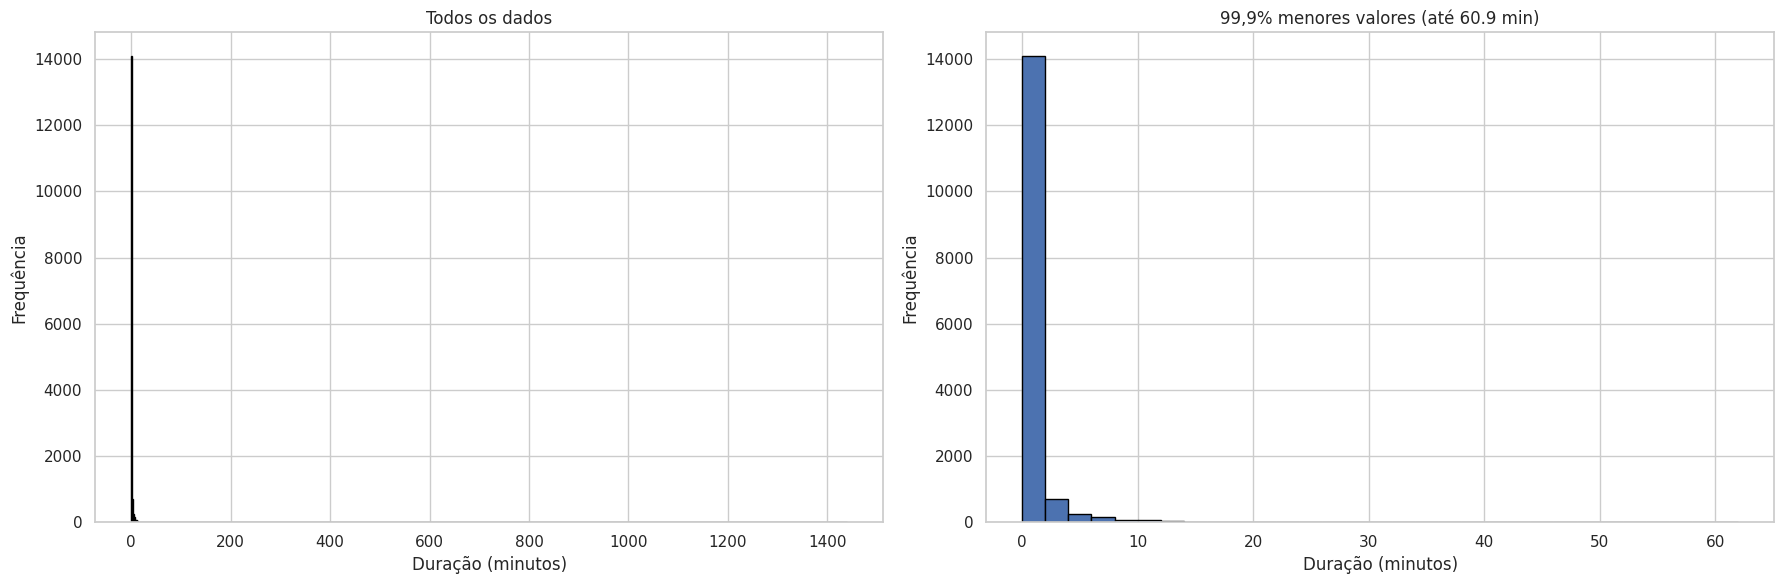

In [156]:
p999 = df3.approxQuantile("trip_duration_min", [0.999], 0.0001)[0]

pdf_completo = df3.select("trip_duration_min").toPandas()
pdf_p999 = df3.filter(F.col("trip_duration_min") <= p999).select("trip_duration_min").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].hist(
    pdf_completo["trip_duration_min"],
    bins=range(0, int(pdf_completo["trip_duration_min"].max()) + 3, 2),
    edgecolor="black"
)
axes[0].set_xlabel("Duração (minutos)")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Todos os dados")

axes[1].hist(
    pdf_p999["trip_duration_min"],
    bins=range(0, int(p999) + 3, 2),
    edgecolor="black"
)
axes[1].set_xlabel("Duração (minutos)")
axes[1].set_ylabel("Frequência")
axes[1].set_title(f"99,9% menores valores (até {p999:.1f} min)")

plt.tight_layout()
plt.show()

O histograma cobre 2 min por barra e é possível enxergar nele que a vasta maioria das corridas restantes com distância zero possui duração de até 2 min o que reforça a tese de que a maioria destas corridas são corridas canceladas.

In [157]:
qtd = df3.filter(F.col("trip_duration_min") <= 6).count()

print(f"Linhas em df3 com trip_duration_min <= 6 min: {qtd}")
print(f"Qtd. menor ou igual que 6 min sobre o total de df3: {qtd} - {qtd / df3.count() * 100:.4f}%")
print(f"Qtd. maior que 6 min sobre o total de df3: {df3.count() - qtd} - {(1 - qtd / df3.count()) * 100:.4f}%")

Linhas em df3 com trip_duration_min <= 6 min: 15064
Qtd. menor ou igual que 6 min sobre o total de df3: 15064 - 97.1370%
Qtd. maior que 6 min sobre o total de df3: 444 - 2.8630%


Dentro de `df3` — registros com `trip_distance == 0`, mesma zona de
embarque e desembarque (`PULocationID == DOLocationID`), excluídos os
casos já explicados por regra tarifária (Flex Fare, Negotiated fare e
JFK↔Manhattan) — **97,14%** (15.064 linhas) têm duração de até 6
minutos, fortemente compatível com cancelamento ou corrida não
iniciada. Os **2,86%** restantes (444 linhas) têm duração superior a 6
minutos apesar de embarque e desembarque na mesma zona — candidatos a
falha de captura de distância em corridas que de fato ocorreram (por
exemplo, trajeto circular dentro da mesma área).

## **9.4. Análise de inconsistências no número de passageiros**

### **9.4.1. passenger_count >= 7**

Durante a exploração dos dados, foram identificadas corridas com valores atípicos na coluna `passenger_count`. De acordo com as regras da [NYC Taxi and Limousine Commission](https://www.nyc.gov/site/tlc/passengers/passenger-frequently-asked-questions.page) (TLC), o número de passageiros permitido em um táxi é limitado a 4 em veículos convencionais e 5 em minivans, admitindo-se um passageiro adicional quando se tratar de criança menor de 7 anos no colo de um adulto. Inicialmente, levantou-se a hipótese de que os registros com valores mais elevados pudessem corresponder a corridas realizadas por limusines, dada a maior capacidade desse tipo de veículo. No entanto, tal hipótese foi descartada, uma vez que o conjunto de dados analisado contempla exclusivamente corridas de táxi (yellow e green taxis), não incluindo serviços prestados por limusines ou outros veículos de maior porte. Dessa forma, registros com `passenger_count` superior a 6 foram classificados como inconsistentes e desconsiderados da análise, por representarem violações às regras operacionais ou prováveis erros de preenchimento por parte do motorista.


``IMPORTANTE``
Enquanto estávamos fazendo a EDA, o texto que tínhamos era: "The maximum amount of passengers allowed in a yellow taxicab by law is four (4) in a four (4) passenger taxicab or five (5) passengers in a five (5) passenger taxicab, except that an additional passenger must be accepted if such passenger is under the age of seven (7) and is held on the lap of an adult passenger seated in the rear."

Porém o atual é: The maximum amount of passengers allowed in a yellow taxicab by law is four (4) in a four (4) passenger taxicab or five (5) passengers in a five (5) passenger taxicab. All passengers must wear seat belts and children under the age of 4 must ride in child safety seats. Children under the age of 8 must ride in a child restraint system, such as a federally approved harness, vest, or booster-seat.

Por convenção, será seguida a regra anterior.


In [159]:
#Total de registros com passageiros >= que 7 e percentual dentro do universo de dados
total = df.count()

df.filter(F.col("passenger_count") >= 7).agg(
    F.count("*").alias("qtd_maior_igual_7"),
    F.round(F.count("*") / F.lit(total) * 100, 4).alias("pct_do_total")
).show()

+-----------------+------------+
|qtd_maior_igual_7|pct_do_total|
+-----------------+------------+
|               60|       0.002|
+-----------------+------------+



### **9.4.2. passenger_count = 0**

Também foram identificados registros de corridas que o nº de passageiros constava como 0. Inicialmente foi criada a hipótese que seriam envio de itens, porém as empresas não fazem envio de itens (colocar fonte). Então o mais plausível é que é um erro de input pelo motorista, invalidando a informação.


In [160]:
#Total de registros com 0 passageiros e percentual dentro do universo de dados
total = df.count()

df.filter(F.col("passenger_count") == 0).agg(
    F.count("*").alias("qtd_zero"),
    F.round(F.count("*") / F.lit(total) * 100, 2).alias("pct_do_total")
).show()

+--------+------------+
|qtd_zero|pct_do_total|
+--------+------------+
|   31465|        1.06|
+--------+------------+



In [161]:
#Exploração dos dados para entender o motivo de 0 passageiros
df.filter(F.col("passenger_count") == 0).select(
    "trip_distance", "fare_amount", "total_amount"
).summary("count", "min", "25%", "50%", "75%", "max").show()

+-------+-------------+-----------+------------+
|summary|trip_distance|fare_amount|total_amount|
+-------+-------------+-----------+------------+
|  count|        31465|      31465|       31465|
|    min|          0.0|      -31.7|       -35.7|
|    25%|          0.9|        7.9|        14.6|
|    50%|          1.5|       11.4|        18.8|
|    75%|          2.7|       17.7|        26.0|
|    max|         60.2|     5000.0|      5000.0|
+-------+-------------+-----------+------------+



In [162]:
# compara com a distribuição geral de vendors
df.filter(F.col("passenger_count") == 0).groupBy("VendorID").count().show()

df.groupBy("VendorID").count().show()

+--------+-----+
|VendorID|count|
+--------+-----+
|       1|31369|
|       2|   96|
+--------+-----+

+--------+-------+
|VendorID|  count|
+--------+-------+
|       1| 729732|
|       2|2234632|
|       6|    260|
+--------+-------+



Total de linhas com passenger_count == 0: 31465
[6.25, 18.8, 42.0, 100.0, 5000.0]


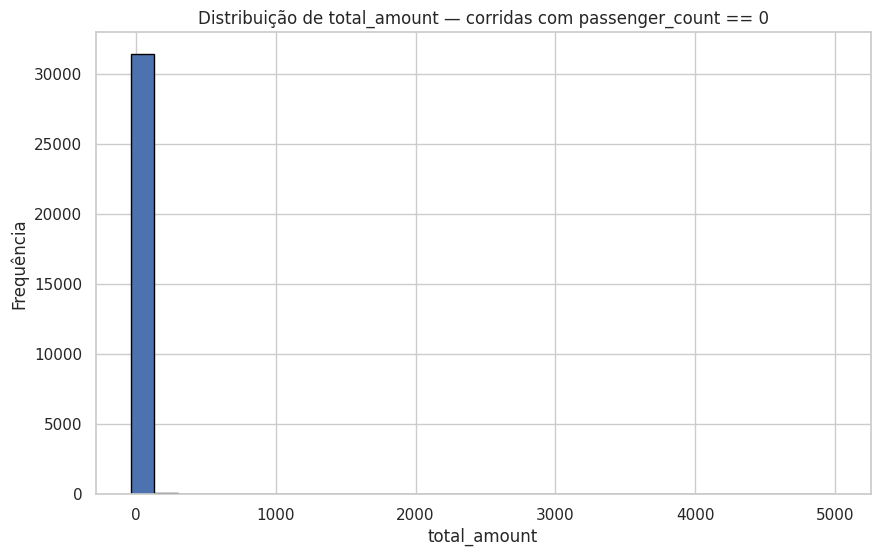

In [163]:
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

zero_passageiros = df.filter(F.col("passenger_count") == 0)

print(f"Total de linhas com passenger_count == 0: {zero_passageiros.count()}")

# Ver os quantis primeiro para calibrar o range do histograma
print(zero_passageiros.approxQuantile("total_amount", [0.01, 0.5, 0.9, 0.99, 1.0], 0.0001))

pdf = zero_passageiros.select("total_amount").toPandas()

plt.figure(figsize=(10, 6))
plt.hist(pdf["total_amount"], bins=30, edgecolor="black")
plt.xlabel("total_amount")
plt.ylabel("Frequência")
plt.title("Distribuição de total_amount — corridas com passenger_count == 0")
plt.show()

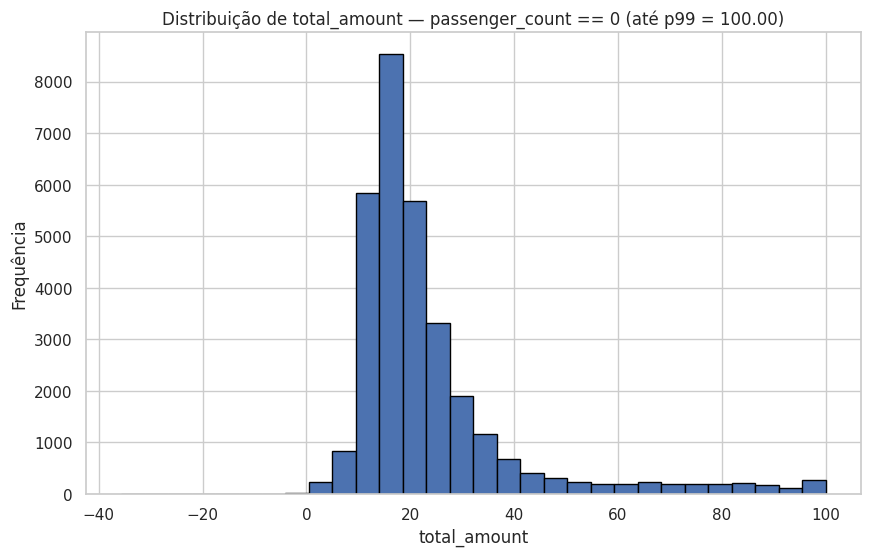

In [164]:
p99 = zero_passageiros.approxQuantile("total_amount", [0.99], 0.0001)[0]

pdf_limitado = zero_passageiros.filter(F.col("total_amount") <= p99).select("total_amount").toPandas()

plt.figure(figsize=(10, 6))
plt.hist(pdf_limitado["total_amount"], bins=30, edgecolor="black")
plt.xlabel("total_amount")
plt.ylabel("Frequência")
plt.title(f"Distribuição de total_amount — passenger_count == 0 (até p99 = {p99:.2f})")
plt.show()

Total de linhas com passenger_count == 0: 31465
[0.13, 10.6, 26.15, 55.75, 130.97]


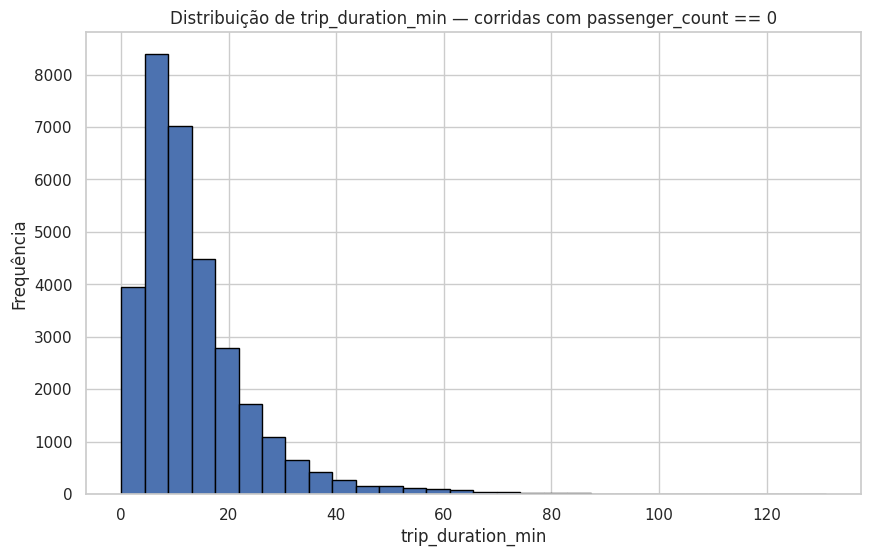

In [165]:
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

zero_passageiros = df.filter(F.col("passenger_count") == 0).cache()

print(f"Total de linhas com passenger_count == 0: {zero_passageiros.count()}")

# Ver os quantis primeiro para calibrar o range do histograma
print(zero_passageiros.approxQuantile("trip_duration_min", [0.01, 0.5, 0.9, 0.99, 1.0], 0.0001))

pdf = zero_passageiros.select("trip_duration_min").toPandas()

plt.figure(figsize=(10, 6))
plt.hist(pdf["trip_duration_min"], bins=30, edgecolor="black")
plt.xlabel("trip_duration_min")
plt.ylabel("Frequência")
plt.title("Distribuição de trip_duration_min — corridas com passenger_count == 0")
plt.show()

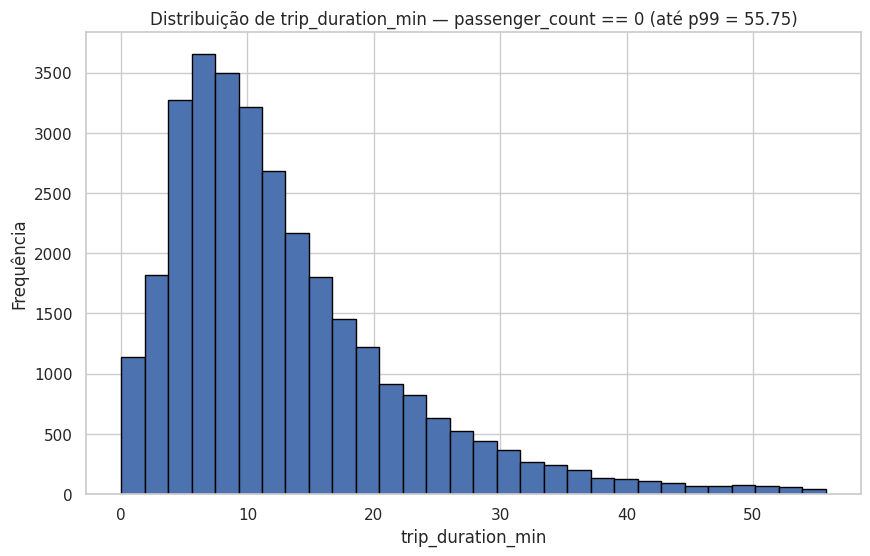

In [166]:
p99 = zero_passageiros.approxQuantile("trip_duration_min", [0.99], 0.0001)[0]

pdf_limitado = zero_passageiros.filter(F.col("trip_duration_min") <= p99).select("trip_duration_min").toPandas()

plt.figure(figsize=(10, 6))
plt.hist(pdf_limitado["trip_duration_min"], bins=30, edgecolor="black")
plt.xlabel("trip_duration_min")
plt.ylabel("Frequência")
plt.title(f"Distribuição de trip_duration_min — passenger_count == 0 (até p99 = {p99:.2f})")
plt.show()

**1.9.3. Valores monetários negativos**

Vamos avaliar os dados negativos por grupo de cada variável categórica:

In [167]:
neg = df.filter(F.col("total_amount") < 0)

categoricas = ["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag"]

for col in categoricas:
    print(f"\n=== {col} ===")

    total_categoria = df.groupBy(col).count().withColumnRenamed("count", "total")
    neg_por_categoria = neg.groupBy(col).count().withColumnRenamed("count", "qtd_negativos")

    resultado = (total_categoria
        .join(neg_por_categoria, total_categoria[col].eqNullSafe(neg_por_categoria[col]), "left")
        .select(
            total_categoria[col],
            "total",
            F.coalesce(F.col("qtd_negativos"), F.lit(0)).alias("qtd_negativos")
        )
        .withColumn("pct_negativos_na_categoria", F.round(F.col("qtd_negativos") / F.col("total") * 100, 4))
        .orderBy(F.desc("pct_negativos_na_categoria")))

    resultado.show()


=== VendorID ===
+--------+-------+-------------+--------------------------+
|VendorID|  total|qtd_negativos|pct_negativos_na_categoria|
+--------+-------+-------------+--------------------------+
|       2|2234632|        35504|                    1.5888|
|       1| 729732|            0|                       0.0|
|       6|    260|            0|                       0.0|
+--------+-------+-------------+--------------------------+


=== RatecodeID ===
+----------+-------+-------------+--------------------------+
|RatecodeID|  total|qtd_negativos|pct_negativos_na_categoria|
+----------+-------+-------------+--------------------------+
|         6|      7|            2|                   28.5714|
|         3|   7954|          335|                    4.2117|
|         5|  19410|          721|                    3.7146|
|         4|   6365|          220|                    3.4564|
|         2|  98713|         2048|                    2.0747|
|         1|2663350|        32176|           

A partir disso pudemos aferir a presença de 35504 registros negativos com incidência única e exclusivamente no VendorID "2 = Curb Mobility, LLC". É possível também identificar uma clara maior incidência destes registros entre os payment_type: 3 = No charge e 4 = Dispute. Devido a este perfil, a hipótese de que tais registros representam reembolsos foi levantada.

Para investigar tal possibilidade investigaremos a existência de linhas duplicatas associadas aos registros negativos (considerando iguais as colunas não-monetárias e de sinal inverso as colunas monetárias).

In [168]:
chave = ["VendorID", "tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count", "trip_distance", "RatecodeID", "store_and_fwd_flag", "PULocationID", "DOLocationID", "payment_type"]

grupos = df.groupBy(chave).count().filter(F.col("count") > 1)
grupos.cache()

print(f"Grupos com mais de uma ocorrência: {grupos.count()}")
print(chave)
grupos.groupBy("count").count().orderBy("count").show()

Grupos com mais de uma ocorrência: 31097
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type']
+-----+-----+
|count|count|
+-----+-----+
|    2|31097|
+-----+-----+



Quantas destas duplicatas apresentam valor idêntico com sinal invertido nas colunas monetárias?

In [169]:
nao_monetarias = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID",
                   "VendorID", "passenger_count", "trip_distance", "RatecodeID",
                   "store_and_fwd_flag", "payment_type"]

monetarias = ["fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
              "improvement_surcharge", "total_amount", "congestion_surcharge", "Airport_fee"]

neg = df.filter(F.col("total_amount") < 0)
pos = df.filter(F.col("total_amount") >= 0)

# Inverte o sinal das monetárias do lado negativo
neg_invertido = neg.select(
    *nao_monetarias,
    *[(-F.col(c)).alias(c) for c in monetarias]
)

# Junção exigindo: não-monetárias idênticas + monetárias (já invertidas) idênticas
pares_exatos = neg_invertido.join(pos, on=nao_monetarias + monetarias, how="inner")

print(f"Duplicatas com não-monetárias idênticas e monetárias exatamente invertidas (número de pares): {pares_exatos.count()}")

Duplicatas com não-monetárias idênticas e monetárias exatamente invertidas (número de pares): 30669


Ou seja, há um forte indício de que estas 30669 linhas com colunas monetárias negativas são reembolsos


No entanto, ainda restam 4835 (35504 - 30669) registros negativos sem explicação. Vamos analisar quantos deles possuem duplicadas apenas considerando as colunas referentes a lugar e tempo ("tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID")

In [170]:
nao_monetarias = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID",
                   "VendorID", "passenger_count", "trip_distance", "RatecodeID",
                   "store_and_fwd_flag", "payment_type"]

monetarias = ["fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
              "improvement_surcharge", "total_amount", "congestion_surcharge", "Airport_fee"]

neg = df.filter(F.col("total_amount") < 0)
pos = df.filter(F.col("total_amount") >= 0)

# Reconstituindo os 4.835 remanescentes (negativos sem par exato pela chave completa)
neg_invertido = neg.select(*nao_monetarias, *[(-F.col(c)).alias(c) for c in monetarias])
pares_exatos_invertido = neg_invertido.join(pos, on=nao_monetarias + monetarias, how="inner")

remanescentes_invertido = neg_invertido.join(
    pares_exatos_invertido.select(*nao_monetarias, *monetarias),
    on=nao_monetarias + monetarias,
    how="left_anti"
)

# Volta ao sinal original (negativo)
remanescentes = remanescentes_invertido.select(*nao_monetarias, *[(-F.col(c)).alias(c) for c in monetarias])

print(f"Remanescentes (negativos sem par exato): {remanescentes.count()}")

# Agora: desses remanescentes, quantos têm alguma correspondência positiva usando SÓ tempo+lugar
chave_4 = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID"]

remanescentes_com_par_frouxo = remanescentes.join(
    pos.select(*chave_4).distinct(),
    on=chave_4,
    how="inner"
)

print(f"Desses remanescentes, quantos têm correspondência positiva por tempo+lugar: {remanescentes_com_par_frouxo.count()}")
print(f"Remanescentes sem correspondência nem por tempo+lugar: {remanescentes.count() - remanescentes_com_par_frouxo.count()}")

Remanescentes (negativos sem par exato): 4835
Desses remanescentes, quantos têm correspondência positiva por tempo+lugar: 432
Remanescentes sem correspondência nem por tempo+lugar: 4403


Uma das hipóteses referentes a estes registros é de que representem reembolsos referentes a corridas ocorridas no mês anterior (dezembro/2023), o que motiva uma investigação.

In [171]:


url_dez_2023 = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-12.parquet"
destino_dez = Path("data/yellow_tripdata_2023-12.parquet")
destino_dez.parent.mkdir(parents=True, exist_ok=True)

if not destino_dez.exists():
    urllib.request.urlretrieve(url_dez_2023, destino_dez)

df_dez_2023 = spark.read.parquet(str(destino_dez))

print(f"Linhas em dezembro/2023: {df_dez_2023.count()}")

Linhas em dezembro/2023: 3376567


In [172]:
chave_4 = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID"]

neg = df.filter(F.col("total_amount") < 0)
pos = df.filter(F.col("total_amount") >= 0)

# Órfãos mesmo sob a chave mais frouxa (tempo + zona)
neg_com_par_frouxo = neg.join(pos.select(*chave_4).distinct(), on=chave_4, how="inner")
orfaos_totais = neg.join(neg_com_par_frouxo.select(*chave_4).distinct(), on=chave_4, how="left_anti")

print(f"Negativos órfãos mesmo com chave frouxa (tempo+zona): {orfaos_totais.count()}")

# Testar correspondência com dezembro/2023, usando a mesma chave frouxa
orfaos_em_dez = orfaos_totais.join(df_dez_2023.select(*chave_4).distinct(), on=chave_4, how="inner")

print(f"Desses órfãos, quantos têm correspondência em dezembro/2023 (mesma chave frouxa): {orfaos_em_dez.count()}")

Negativos órfãos mesmo com chave frouxa (tempo+zona): 4403
Desses órfãos, quantos têm correspondência em dezembro/2023 (mesma chave frouxa): 0


**Decisão: exclusão dos negativos órfãos**

Dos 35.504 registros com `total_amount` negativo, 30.669 (86,4%)
possuem uma contraparte positiva idêntica nas colunas não-monetárias e
exatamente invertida nas colunas monetárias — o padrão de lançamento e
estorno já caracterizado nesta seção. Os 4.835 registros restantes
(13,6% dos negativos; 0,16% da base total) não apresentam
correspondência identificável sob nenhuma das definições de chave
testadas.

**Investigação realizada:**

- Correspondência exata em todas as 19 colunas — nenhuma encontrada.
- Correspondência exigindo igualdade nas 10 colunas não-monetárias e
  inversão exata nas 9 monetárias — nenhuma encontrada.
- Correspondência sob chave frouxa, considerando apenas tempo e
  localização (`tpep_pickup_datetime`, `tpep_dropoff_datetime`,
  `PULocationID`, `DOLocationID`), sem exigir igualdade em nenhum outro
  atributo — nenhuma encontrada.
- Correspondência com o arquivo de dezembro/2023, sob a hipótese de que
  o lançamento original estivesse fora do recorte de janeiro — nenhuma
  encontrada, sob qualquer uma das definições de chave acima.

**Hipóteses consideradas e não confirmáveis com os dados
disponíveis:** lançamento original não exportado pelo provedor;
correção simultânea de atributos operacionais no momento do estorno;
ajuste interno sem contraparte simples de lançamento. Nenhuma fonte
oficial da TLC documenta o mecanismo de estorno ou explica a origem
desses registros.

**Decisão:** os 4.835 registros foram **excluídos da tabela fato**,
sob o grão "uma linha = uma corrida" — como não há evidência de que
representem uma viagem capturada na base, sua permanência distorceria
contagens e métricas sem possibilidade de correção. Os registros
originais foram preservados integralmente na tabela de auditoria
`negativos_orfaos_causa_indeterminada`, garantindo rastreabilidade
total e possibilidade de revisão futura caso surja nova evidência.

**Materialidade:** o volume envolvido (0,16% da base) não compromete
a validade de nenhuma métrica agregada da fato final.

# **10. Consolidação dos achados**

## 10.1 Consolidando Análise de outliers e anomalias

**Nº de registros de corridas fora do domínio esperado de janeiro:** 18 (0,0006%)

**Ação:** Deletar os registros.

**Nº de registros de outliers de ``trip_duration_min``:** 1.651 (0,0557%)

**Ação:** Deletar os registros com trip_duration_min > 10h.

**Nº de registros de corridas com tempo negativo:** 56 (0,0019%)

**Ação:** Deletar os registros.

---

## 10.2. Análise de inconsistências monetárias

**Nº de registros em que o `total_amount` é divergente da soma dos demais valores:** 761.838 (25,6976%)

**Ação:** Recalcular a coluna `total_amount`, se todas as hipóteses das diferenças forem validadas.

#### 10.2.2. Análise de outliers e valores anômalos em `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `congestion_surcharge`, `Airport_fee`, `fare_amount`
**Nº de registros:**
- `mta_tax`: 9 (0,0003%)
- `improvement_surcharge`: 574 (0,0194%)
- `congestion_surcharge`: 5 (0,0002%)
- `extra`: 17548 (0.59%) valores negativos.
- `tip_amount`: tip_amount não é problemático em sí, pois em taxís que a opção de pagamento foi tarifa negociada, o valor da corrida estava sendo embutido em tip_amount.
- `tolls_amount`: Temos cerca de 2000 linhas negativas
- `fare_amount`: 39958 (1.34%) fare_amount contem muito ruído de valores negativos e abaixo do valor minimo que é $3.00, além de outliers superiores de uma forte assimetria positiva
- `Airport_fee`: 0 (nenhum registro fora do domínio)

**Ação:**
- `mta_tax`: deletar registros anômalos
- `improvement_surcharge`: deletar devido ao baixo número de registros — valor (0,30) corresponde à taxa historicamente vigente entre 2015 e 2022, hoje desatualizada
- `congestion_surcharge`: deletar registros anômalos
- `Airport_fee`: justificar valor defasado (atualmente USD 2,00; à época da base, USD 1,75)
- `extra`, `tip_amount`, `tolls_amount`, `fare_amount`: **pendente de quantificação e decisão**⚠️

#### **10.2.3. Valores monetários negativos**
**Nº de registros:**
- Todos os valores monetários não-positivos **com** par positivo: **pendente de contagem**
- Todos os valores monetários não-positivos **sem** par positivo (órfãos): 4.835 (0,1631%)

**Ação:**
- Com par positivo: apagar os negativos com par positivo (considerados reembolso; a exclusão garante a granularidade a nível de corrida)
- Sem par positivo (órfãos): excluir da fato — após a exclusão, restam 481 registros nesta categoria (**verificar se este número já reflete algum filtro adicional aplicado, dado que difere do total de 4.835 órfãos**)



In [173]:
tips_acima_200 = (
    df
    .filter(
        (F.col("tip_amount") > 100) &
        (F.col("trip_distance") >= 0)
    )
    .orderBy(F.col("tip_amount").desc())
)

tips_acima_200.show(truncate=False)      # todas as colunas
print("total de registros:", tips_acima_200.count())

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+-----------------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|trip_duration_min|average_speed_mph |
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+-----------------+------------------+
|1       |2024-01-29 13:30:58 |2024-01-29 13:31:08  |1              |0.0    






---

## 10.3. Análise de inconsistências em distância

**Nº de registros com distâncias irreais em `trip_distance`:** 1.107 (0,0373%)

**Ação:** Deletar os registros com `velocidade_mph > 80`.

**Nº de registros de `trip_distance` == 0 (% sobre o total da base):**
- `trip_distance == 0` e `payment_type == 0` (Flex Fare): 22.825 (0,7700%)
- `trip_distance == 0` e `RatecodeID == 2`, no translado JFK ↔ Manhattan: 105 (0,0035%)
- `trip_distance == 0` e `RatecodeID == 5`: 10.210 (0,3444%)
- Demais casos, fora das 3 condições acima e `trip_distance == 0`: 27.231 (0,9184%)
  - `PULocationID != DOLocationID`: 11.723 (0,3954%)
  - `PULocationID == DOLocationID`: 15.508 (0,5231%)

**Ação:**
- `RatecodeID == 2`, no translado JFK ↔ Manhattan: calcular a moda e criar flag sinalizando estimação
- `RatecodeID == 5`: calcular a moda e criar flag sinalizando estimação
- `PULocationID != DOLocationID` (demais casos): calcular a moda e criar flag sinalizando estimação
- `PULocationID == DOLocationID`: deletar registro se `duracao_min < 4 min` - corrida cancelada

---

**Nº de registros em que passenger_count >= 7:** 60 (0,0020%)

**Ação:** Deletar registros, pois segundo a comissão de taxi de e limousines de NY, o máx são 6 passageiros em um taxicab.


**Nº de registros em que passenger_count == 0:** 31.465 (1,0613%)

**Ação:** **Registros foram considerados inválidos, pois pode ser um erro de input ou uma tentativa de bater meta de quantidade de corridas de um taxista**